# EDA Notebook — Deescuy Kaggle Competition

Notebook ini fokus **khusus pada tahap exploratory data analysis (EDA)** untuk kompetisi prediksi skor pertandingan, dengan target:

- `team_goals`
- `opp_goals`

Tujuan notebook ini bukan langsung membuat pipeline modeling, tetapi mencari insight yang bisa membantu memilih pendekatan yang paling cocok nanti.

## Cakupan EDA di notebook ini

Notebook ini mengerjakan 15 area EDA:

1. Audit struktur data  
2. EDA target utama  
3. EDA pertandingan ekstrem / blowout  
4. EDA temporal  
5. EDA train–test shift  
6. EDA berdasarkan gender  
7. EDA berdasarkan tournament  
8. EDA home / neutral  
9. EDA missing values dan kualitas data  
10. EDA fitur common vs train-only  
11. EDA hubungan fitur dengan target  
12. EDA tim dan matchup  
13. EDA era modern vs era lama  
14. EDA yang membantu desain validasi  
15. EDA rare categories  

> Catatan: dataset kompetisi berbentuk **2 row per match**, jadi sebagian analisis dilakukan di level row, dan sebagian lain di level match.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

try:
    from scipy.stats import ks_2samp
except Exception:
    ks_2samp = None

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 11
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)

def resolve_file(name: str) -> Path:
    candidates = [
        Path(name),
        Path("data") / name,
        Path("../dataset") / name,
        Path("/mnt/data") / name,
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(
        f"File {name} tidak ditemukan. Coba taruh file di folder yang sama dengan notebook, folder data/, atau /mnt/data."
    )

def pct(x):
    return f"{x:.2%}"

def capped_counts(series, cap=10):
    s = series.fillna(-1)
    labels = list(range(cap + 1))
    counts = []
    for v in labels[:-1]:
        counts.append((s == v).sum())
    counts.append((s >= cap).sum())
    idx = [str(v) for v in labels[:-1]] + [f"{cap}+"]
    return pd.Series(counts, index=idx)

def compare_category_distribution(train_series, test_series, top_n=10):
    train_share = train_series.value_counts(normalize=True)
    test_share = test_series.value_counts(normalize=True)
    cats = (train_series.value_counts().head(top_n).index
            .union(test_series.value_counts().head(top_n).index))
    out = pd.DataFrame({
        "train_share": train_share.reindex(cats, fill_value=0.0),
        "test_share": test_share.reindex(cats, fill_value=0.0),
    }).reset_index().rename(columns={"index": "category"})
    out["abs_diff"] = (out["train_share"] - out["test_share"]).abs()
    return out.sort_values("abs_diff", ascending=False).reset_index(drop=True)

def make_match_level(df, include_targets=True):
    meta_cols = [
        "match_id", "date", "year", "gender", "neutral", "tournament",
        "venue_country", "altitude_venue_clean", "temperature_venue"
    ]
    meta = df.groupby("match_id")[meta_cols[1:]].first().reset_index()

    home = df[df["is_home"] == 1].copy()
    away = df[df["is_home"] == 0].copy()

    def rename_side(side_df, prefix):
        rename_map = {
            "team": f"{prefix}_team",
            "confederation_team": f"{prefix}_confederation",
            "population_team": f"{prefix}_population",
            "gdp_per_capita_team": f"{prefix}_gdp_per_capita",
            "distance_travel_team": f"{prefix}_distance_travel",
        }
        if include_targets and "team_goals" in side_df.columns:
            rename_map["team_goals"] = f"{prefix}_goals"
        keep = ["match_id"] + list(rename_map.keys())
        return side_df[keep].rename(columns=rename_map)

    match_df = meta.merge(rename_side(home, "home"), on="match_id", how="left")
    match_df = match_df.merge(rename_side(away, "away"), on="match_id", how="left")

    if include_targets and {"home_goals", "away_goals"}.issubset(match_df.columns):
        match_df["total_goals"] = match_df["home_goals"] + match_df["away_goals"]
        match_df["goal_diff"] = match_df["home_goals"] - match_df["away_goals"]
        match_df["abs_goal_diff"] = match_df["goal_diff"].abs()
        match_df["scoreline"] = match_df["home_goals"].astype(str) + "-" + match_df["away_goals"].astype(str)
        match_df["outcome"] = np.where(
            match_df["goal_diff"] > 0, "Home Win",
            np.where(match_df["goal_diff"] < 0, "Away Win", "Draw")
        )
    return match_df

def qcut_with_labels(series, q=10, precision=1):
    s = series.dropna()
    if s.nunique() < 3:
        return pd.Series(index=series.index, dtype="object")
    try:
        bins = pd.qcut(s, q=min(q, s.nunique()), duplicates="drop")
    except Exception:
        return pd.Series(index=series.index, dtype="object")
    labels = [f"{iv.left:.{precision}f} – {iv.right:.{precision}f}" for iv in bins.cat.categories]
    out = pd.Series(
        index=s.index,
        data=pd.Categorical.from_codes(bins.cat.codes, categories=labels, ordered=True)
    )
    return out.reindex(series.index)

def style_pct_columns(df, pct_cols):
    styled = df.copy()
    for c in pct_cols:
        if c in styled.columns:
            styled[c] = styled[c].map(lambda x: f"{x:.2%}" if pd.notna(x) else np.nan)
    return styled

train_path = resolve_file("train.csv")
test_path = resolve_file("test.csv")

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

original_train_cols = train.columns.tolist()
original_test_cols = test.columns.tolist()

for df in (train, test):
    df["date"] = pd.to_datetime(df["date"])
    df["year"] = df["date"].dt.year
    df["altitude_venue_clean"] = df["altitude_venue"].replace(-9999, np.nan)
    df["avg_travel_distance"] = df[["distance_travel_team", "distance_travel_opp"]].mean(axis=1)

common_cols = sorted(set(original_train_cols) & set(original_test_cols))
train_only_cols = sorted(set(original_train_cols) - set(original_test_cols))

train_match = make_match_level(train, include_targets=True)
test_match = make_match_level(test, include_targets=False)

print(f"Train path : {train_path}")
print(f"Test path  : {test_path}")
print(f"Train rows : {len(train):,}")
print(f"Test rows  : {len(test):,}")
print(f"Train match: {train_match['match_id'].nunique():,}")
print(f"Test match : {test_match['match_id'].nunique():,}")

Train path : ..\dataset\train.csv
Test path  : ..\dataset\test.csv
Train rows : 78,772
Test rows  : 42,422
Train match: 39,386
Test match : 21,211


## 1. Audit struktur data

Bagian ini menjawab pertanyaan dasar:

- apakah memang benar tiap pertandingan punya 2 baris,
- apakah pasangan dua baris itu konsisten,
- apakah metadata per match stabil,
- dan bagaimana relasi train vs test dari sisi kolom.

In [2]:
overview_df = pd.DataFrame({
    "dataset": ["train", "test"],
    "rows": [len(train), len(test)],
    "matches": [train["match_id"].nunique(), test["match_id"].nunique()],
    "columns": [len(original_train_cols), len(original_test_cols)],
    "date_min": [train["date"].min().date(), test["date"].min().date()],
    "date_max": [train["date"].max().date(), test["date"].max().date()],
})

print("Ringkasan dataset")
display(overview_df)

print()
print("Jumlah row per match_id")
display(pd.DataFrame({
    "train": train.groupby("match_id").size().value_counts().sort_index(),
    "test": test.groupby("match_id").size().value_counts().sort_index(),
}).fillna(0).astype(int))

print()
print("Kolom yang sama di train dan test:", len(common_cols))
display(pd.DataFrame({"common_columns": common_cols}))

print()
print("Kolom yang hanya ada di train:", len(train_only_cols))
display(pd.DataFrame({"train_only_columns": train_only_cols}))

print()
print("Preview train")
display(train.head(3))
print()
print("Preview test")
display(test.head(3))

Ringkasan dataset


,dataset,rows,matches,columns,date_min,date_max
0,train,78772,39386,47,1872-11-30,2011-08-04
1,test,42422,21211,20,2011-08-06,2026-03-31



Jumlah row per match_id


,train,test
2,39386,21211



Kolom yang sama di train dan test: 20


...

,train_only_columns
0,days_since_last_match_opp
1,days_since_last_match_team
2,elo_opponent
3,elo_team
4,gd_last5_diff
5,h2h_gd_last5
6,h2h_points_last5
7,opp_avg_conceded_last5
8,opp_avg_goals_last5
9,opp_gd_last5



Preview train


,Id,match_id,date,gender,team,opponent,is_home,neutral,tournament,venue_country,team_goals,opp_goals,team_points_last5,opp_points_last5,points_last5_diff,team_gd_last5,opp_gd_last5,gd_last5_diff,h2h_points_last5,h2h_gd_last5,days_since_last_match_team,days_since_last_match_opp,team_points_last10,opp_points_last10,team_avg_goals_last5,team_avg_conceded_last5,opp_avg_goals_last5,opp_avg_conceded_last5,team_win_rate_last10,opp_win_rate_last10,elo_team,elo_opponent,rank_team,rank_opponent,rank_diff,rank_missing_team,rank_missing_opp,confederation_team,confederation_opp,population_team,population_opp,gdp_per_capita_team,gdp_per_capita_opp,altitude_venue,distance_travel_team,distance_travel_opp,temperature_venue,year,altitude_venue_clean,avg_travel_distance
0,M000001_Scotland,M000001,1872-11-30,M,Scotland,England,1,0,Friendly,Scotland,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1500.0,1500.0,NaN,NaN,NaN,1,1,UEFA,UEFA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1872,NaN,NaN
1,M000001_England,M000001,1872-11-30,M,England,Scotland,0,0,Friendly,Scotland,0,0,NaN,1.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,1.0,NaN,NaN,0.0,0.0,NaN,0.0,1500.0,1500.0,NaN,NaN,NaN,1,1,UEFA,UEFA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1872,NaN,NaN
2,M000002_England,M000002,1873-03-08,M,England,Scotland,1,0,Friendly,England,4,2,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,98.0,98.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1500.0,1500.0,NaN,NaN,NaN,1,1,UEFA,UEFA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1873,NaN,NaN



Preview test


,Id,match_id,date,gender,team,opponent,is_home,neutral,tournament,venue_country,confederation_team,confederation_opp,population_team,population_opp,gdp_per_capita_team,gdp_per_capita_opp,altitude_venue,distance_travel_team,distance_travel_opp,temperature_venue,year,altitude_venue_clean,avg_travel_distance
0,M034984_Seychelles,M034984,2011-08-06,M,Seychelles,Mauritius,1,0,Indian Ocean Island Games,Seychelles,CAF,CAF,92409.0,1283330.0,12189.095160,9197.026972,-9999.0,0.000000,1751.895724,25.790169,2011,NaN,875.947862
1,M034984_Mauritius,M034984,2011-08-06,M,Mauritius,Seychelles,0,0,Indian Ocean Island Games,Seychelles,CAF,CAF,1283330.0,92409.0,9197.026972,12189.095160,-9999.0,1751.895724,0.000000,25.790169,2011,NaN,875.947862
2,M034985_Comoros,M034985,2011-08-06,M,Comoros,Maldives,1,1,Indian Ocean Island Games,Seychelles,CAF,AFC,656024.0,361575.0,1447.945144,7291.465967,-9999.0,1517.010705,5483.117523,25.790169,2011,NaN,3500.064114


In [3]:
match_sizes_train = train.groupby("match_id").size()
match_sizes_test = test.groupby("match_id").size()

meta_consistency = (
    train.groupby("match_id")[["date", "gender", "neutral", "tournament", "venue_country"]]
    .nunique()
)

goal_mirror = (
    train.groupby("match_id")[["team_goals", "opp_goals"]]
    .agg(list)
)

goal_mirror_ok = goal_mirror.apply(
    lambda row: sorted(row["team_goals"]) == sorted(row["opp_goals"]), axis=1
)

team_swap = train.groupby("match_id")[["team", "opponent"]].agg(list)
team_swap_ok = team_swap.apply(
    lambda row: set(row["team"]) == set(row["opponent"]), axis=1
)

home_count = train.groupby("match_id")["is_home"].sum()

audit_summary = pd.DataFrame({
    "check": [
        "Semua match train punya tepat 2 row",
        "Semua match test punya tepat 2 row",
        "Setiap match train punya tepat 1 home-side",
        "Metadata match train konsisten dalam 2 row",
        "Target team_goals/opp_goals mirror antar 2 row",
        "Kolom team/opponent saling swap antar 2 row",
    ],
    "result": [
        (match_sizes_train == 2).all(),
        (match_sizes_test == 2).all(),
        (home_count == 1).all(),
        (meta_consistency.max(axis=1) == 1).all(),
        goal_mirror_ok.all(),
        team_swap_ok.all(),
    ]
})

display(audit_summary)

insight_lines = [
    "**Insight cepat:**",
    "",
    "- Format data memang konsisten sebagai **2 row per match**.",
    f"- Train berakhir di **{train['date'].max().date()}**, sedangkan test mulai di **{test['date'].min().date()}**.",
    f"- Ada **{len(train_only_cols)} kolom train-only**, jadi tidak semua pola yang kita temukan nanti bisa langsung dipakai saat inference.",
]
display(Markdown(chr(10).join(insight_lines)))

,check,result
0,Semua match train punya tepat 2 row,True
1,Semua match test punya tepat 2 row,True
2,Setiap match train punya tepat 1 home-side,True
3,Metadata match train konsisten dalam 2 row,True
4,Target team_goals/opp_goals mirror antar 2 row,True
5,Kolom team/opponent saling swap antar 2 row,True


**Insight cepat:**

- Format data memang konsisten sebagai **2 row per match**.
- Train berakhir di **2011-08-04**, sedangkan test mulai di **2011-08-06**.
- Ada **27 kolom train-only**, jadi tidak semua pola yang kita temukan nanti bisa langsung dipakai saat inference.

## 2. EDA target utama

Karena target akhir adalah `team_goals` dan `opp_goals`, bagian ini melihat:

- distribusi gol per sisi,
- distribusi total gol per match,
- distribusi selisih gol,
- exact scoreline yang paling sering muncul.

,mean,median,std,min,max
team_goals,1.563119,1.0,1.792137,0.0,31.0
opp_goals,1.563119,1.0,1.792137,0.0,31.0


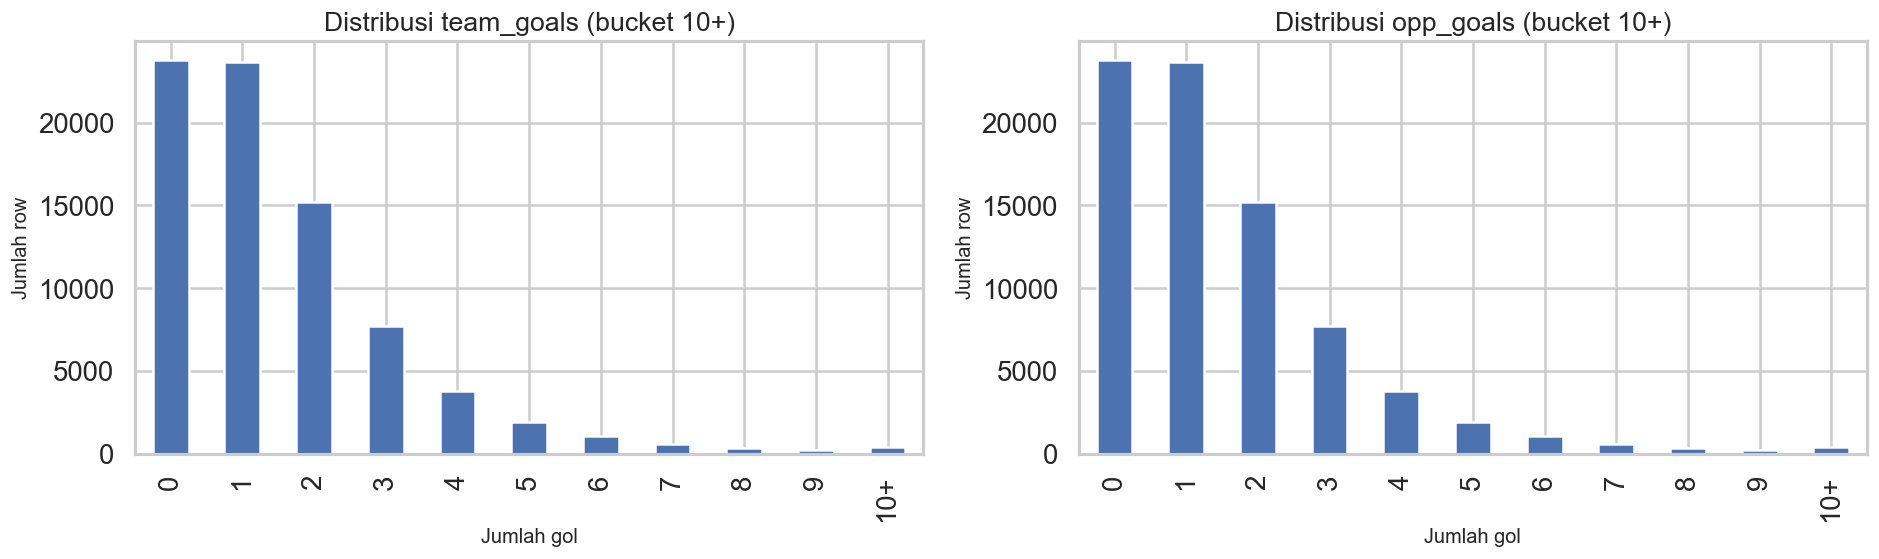

**Catatan singkat:**

- Rata-rata `team_goals` = **1.563**
- Median `team_goals` = **1**
- Proporsi row dengan `team_goals = 0` = **30.15%**
- Nilai maksimum `team_goals` = **31**

In [4]:
row_target_summary = train[["team_goals", "opp_goals"]].agg(["mean", "median", "std", "min", "max"]).T
display(row_target_summary)

team_goal_counts = capped_counts(train["team_goals"], cap=10)
opp_goal_counts = capped_counts(train["opp_goals"], cap=10)

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
team_goal_counts.plot(kind="bar", ax=ax[0])
ax[0].set_title("Distribusi team_goals (bucket 10+)")
ax[0].set_xlabel("Jumlah gol")
ax[0].set_ylabel("Jumlah row")

opp_goal_counts.plot(kind="bar", ax=ax[1])
ax[1].set_title("Distribusi opp_goals (bucket 10+)")
ax[1].set_xlabel("Jumlah gol")
ax[1].set_ylabel("Jumlah row")

plt.tight_layout()
plt.show()

insight_lines = [
    "**Catatan singkat:**",
    "",
    f"- Rata-rata `team_goals` = **{train['team_goals'].mean():.3f}**",
    f"- Median `team_goals` = **{train['team_goals'].median():.0f}**",
    f"- Proporsi row dengan `team_goals = 0` = **{pct((train['team_goals'] == 0).mean())}**",
    f"- Nilai maksimum `team_goals` = **{train['team_goals'].max()}**",
]
display(Markdown(chr(10).join(insight_lines)))

,mean,median,std,min,max
home_goals,1.888717,1.0,1.984754,0.0,31.0
away_goals,1.237521,1.0,1.507419,0.0,24.0
total_goals,3.126238,3.0,2.274366,0.0,31.0
goal_diff,0.651196,1.0,2.692653,-22.0,31.0
abs_goal_diff,1.879856,1.0,2.034821,0.0,31.0


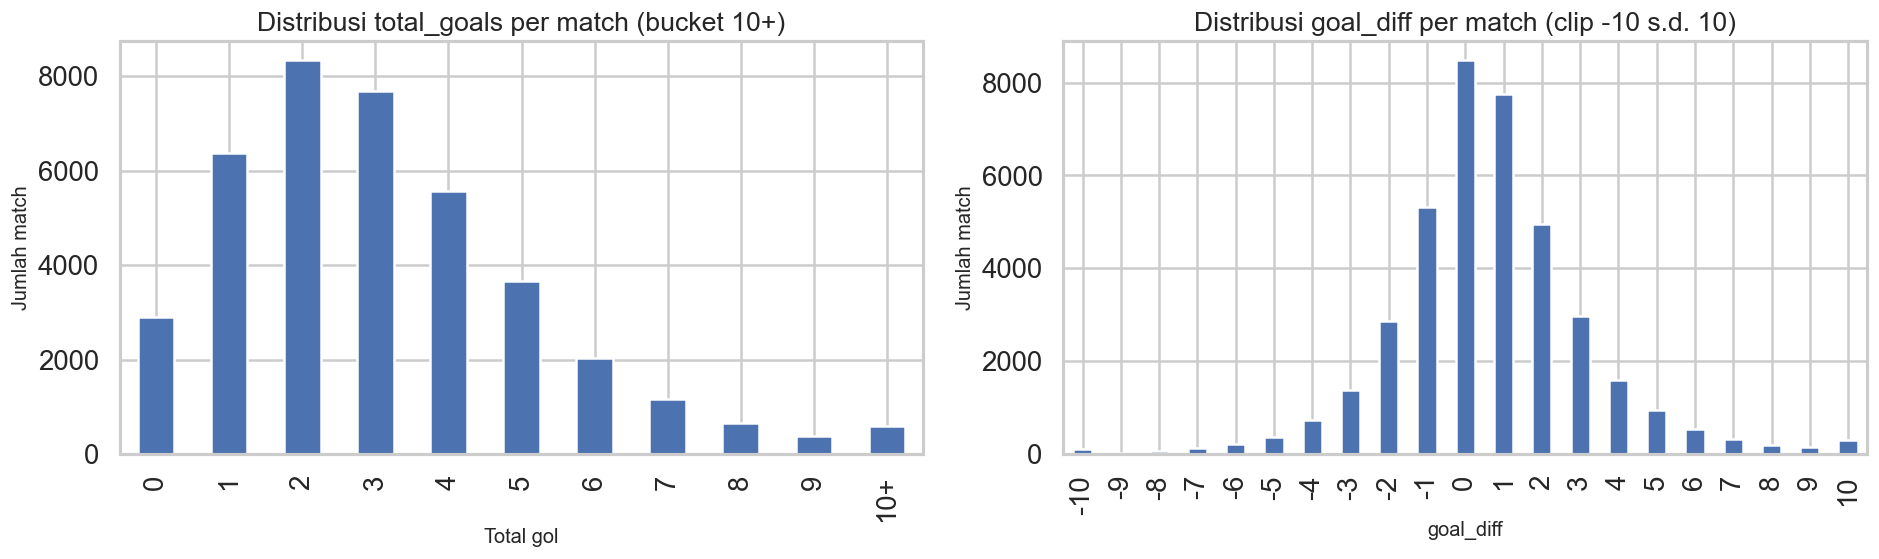

,scoreline,matches
0,1-0,3784
1,1-1,3693
2,2-1,2956
3,2-0,2946
4,0-0,2911
5,0-1,2598
6,1-2,1947
7,3-0,1916
8,0-2,1696
9,3-1,1561


**Insight cepat:**

- Rata-rata total gol per match = **3.126**
- Median total gol per match = **3**
- Exact scoreline paling umum = **1-0** dengan **3,784 match**

In [5]:
match_target_summary = train_match[["home_goals", "away_goals", "total_goals", "goal_diff", "abs_goal_diff"]].agg(
    ["mean", "median", "std", "min", "max"]
).T
display(match_target_summary)

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

capped_counts(train_match["total_goals"], cap=10).plot(kind="bar", ax=ax[0])
ax[0].set_title("Distribusi total_goals per match (bucket 10+)")
ax[0].set_xlabel("Total gol")
ax[0].set_ylabel("Jumlah match")

goal_diff_clip = train_match["goal_diff"].clip(-10, 10)
goal_diff_counts = goal_diff_clip.value_counts().sort_index()
goal_diff_counts.index = goal_diff_counts.index.astype(str)
goal_diff_counts.plot(kind="bar", ax=ax[1])
ax[1].set_title("Distribusi goal_diff per match (clip -10 s.d. 10)")
ax[1].set_xlabel("goal_diff")
ax[1].set_ylabel("Jumlah match")

plt.tight_layout()
plt.show()

top_scorelines = (
    train_match["scoreline"]
    .value_counts()
    .rename_axis("scoreline")
    .reset_index(name="matches")
    .head(15)
)
display(top_scorelines)

insight_lines = [
    "**Insight cepat:**",
    "",
    f"- Rata-rata total gol per match = **{train_match['total_goals'].mean():.3f}**",
    f"- Median total gol per match = **{train_match['total_goals'].median():.0f}**",
    f"- Exact scoreline paling umum = **{top_scorelines.iloc[0, 0]}** dengan **{top_scorelines.iloc[0, 1]:,} match**",
]
display(Markdown(chr(10).join(insight_lines)))

## 3. EDA pertandingan ekstrem / blowout

Tujuannya untuk melihat seberapa sering pertandingan sangat high-scoring atau sangat timpang terjadi. Ini penting karena model skor sering bagus di kasus normal, tapi meleset di kasus ekstrem.

,condition,share
0,total_goals >= 4,35.72%
1,total_goals >= 6,12.27%
2,total_goals >= 8,4.15%
3,total_goals >= 10,1.53%
4,abs_goal_diff >= 2,45.28%
5,abs_goal_diff >= 4,14.41%
6,abs_goal_diff >= 6,5.23%


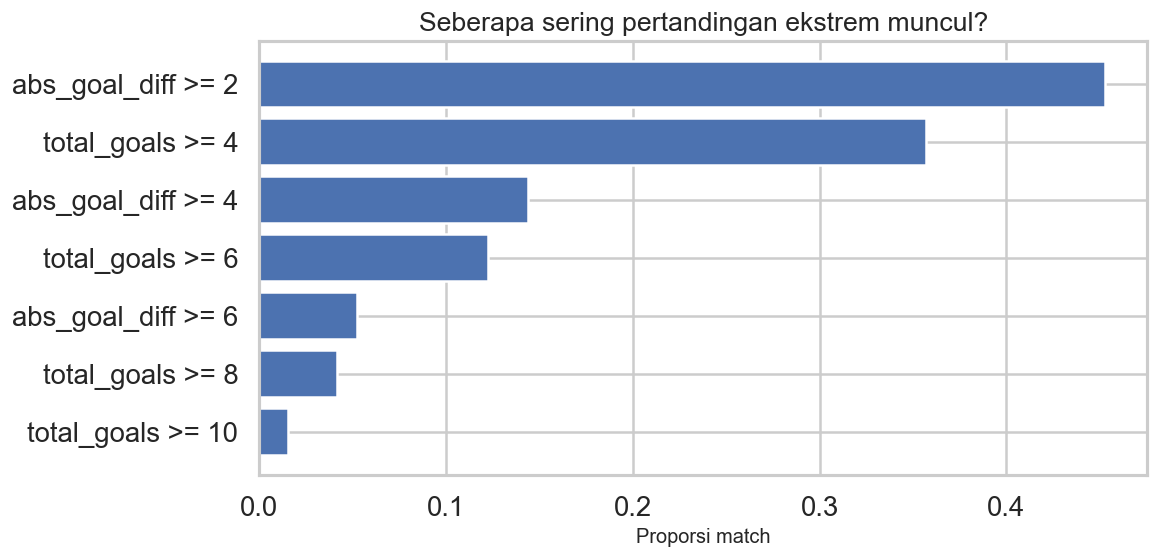

,date,gender,tournament,home_team,away_team,home_goals,away_goals,total_goals,abs_goal_diff
25421,2001-04-11,M,FIFA World Cup qualification,Australia,American Samoa,31,0,31,31
8546,1971-09-13,M,South Pacific Games,Tahiti,Cook Islands,30,0,30,30
37945,2006-11-10,W,African Championship,Cameroon,South Africa,2,24,26,22
11913,1979-08-30,M,South Pacific Games,Fiji,Kiribati,24,0,24,24
36826,2001-12-06,W,AFC Championship,North Korea,Singapore,24,0,24,24
25417,2001-04-09,M,FIFA World Cup qualification,Australia,Tonga,22,0,22,22
30513,2006-11-24,M,Viva World Cup,Sápmi,Monaco,21,1,22,20
6576,1966-04-03,M,Arab Cup,Libya,Oman,21,0,21,21
29040,2005-03-11,M,EAFF Championship,Guam,North Korea,0,21,21,21
35870,1995-09-24,W,AFC Championship,China PR,Philippines,21,0,21,21


In [6]:
threshold_summary = pd.DataFrame({
    "condition": [
        "total_goals >= 4",
        "total_goals >= 6",
        "total_goals >= 8",
        "total_goals >= 10",
        "abs_goal_diff >= 2",
        "abs_goal_diff >= 4",
        "abs_goal_diff >= 6",
    ],
    "share": [
        (train_match["total_goals"] >= 4).mean(),
        (train_match["total_goals"] >= 6).mean(),
        (train_match["total_goals"] >= 8).mean(),
        (train_match["total_goals"] >= 10).mean(),
        (train_match["abs_goal_diff"] >= 2).mean(),
        (train_match["abs_goal_diff"] >= 4).mean(),
        (train_match["abs_goal_diff"] >= 6).mean(),
    ]
})
display(style_pct_columns(threshold_summary, ["share"]))

fig, ax = plt.subplots(figsize=(10, 5))
plot_df = threshold_summary.sort_values("share")
ax.barh(plot_df["condition"], plot_df["share"])
ax.set_title("Seberapa sering pertandingan ekstrem muncul?")
ax.set_xlabel("Proporsi match")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

extreme_matches = (
    train_match.sort_values(["total_goals", "abs_goal_diff"], ascending=False)
    [["date", "gender", "tournament", "home_team", "away_team", "home_goals", "away_goals", "total_goals", "abs_goal_diff"]]
    .head(20)
)
display(extreme_matches)

## 4. EDA temporal

Karena train dan test dipisahkan berdasarkan waktu, kita perlu melihat:

- jumlah match per tahun,
- bagaimana rata-rata gol berubah dari waktu ke waktu,
- bagaimana draw rate dan home win rate ikut berubah.

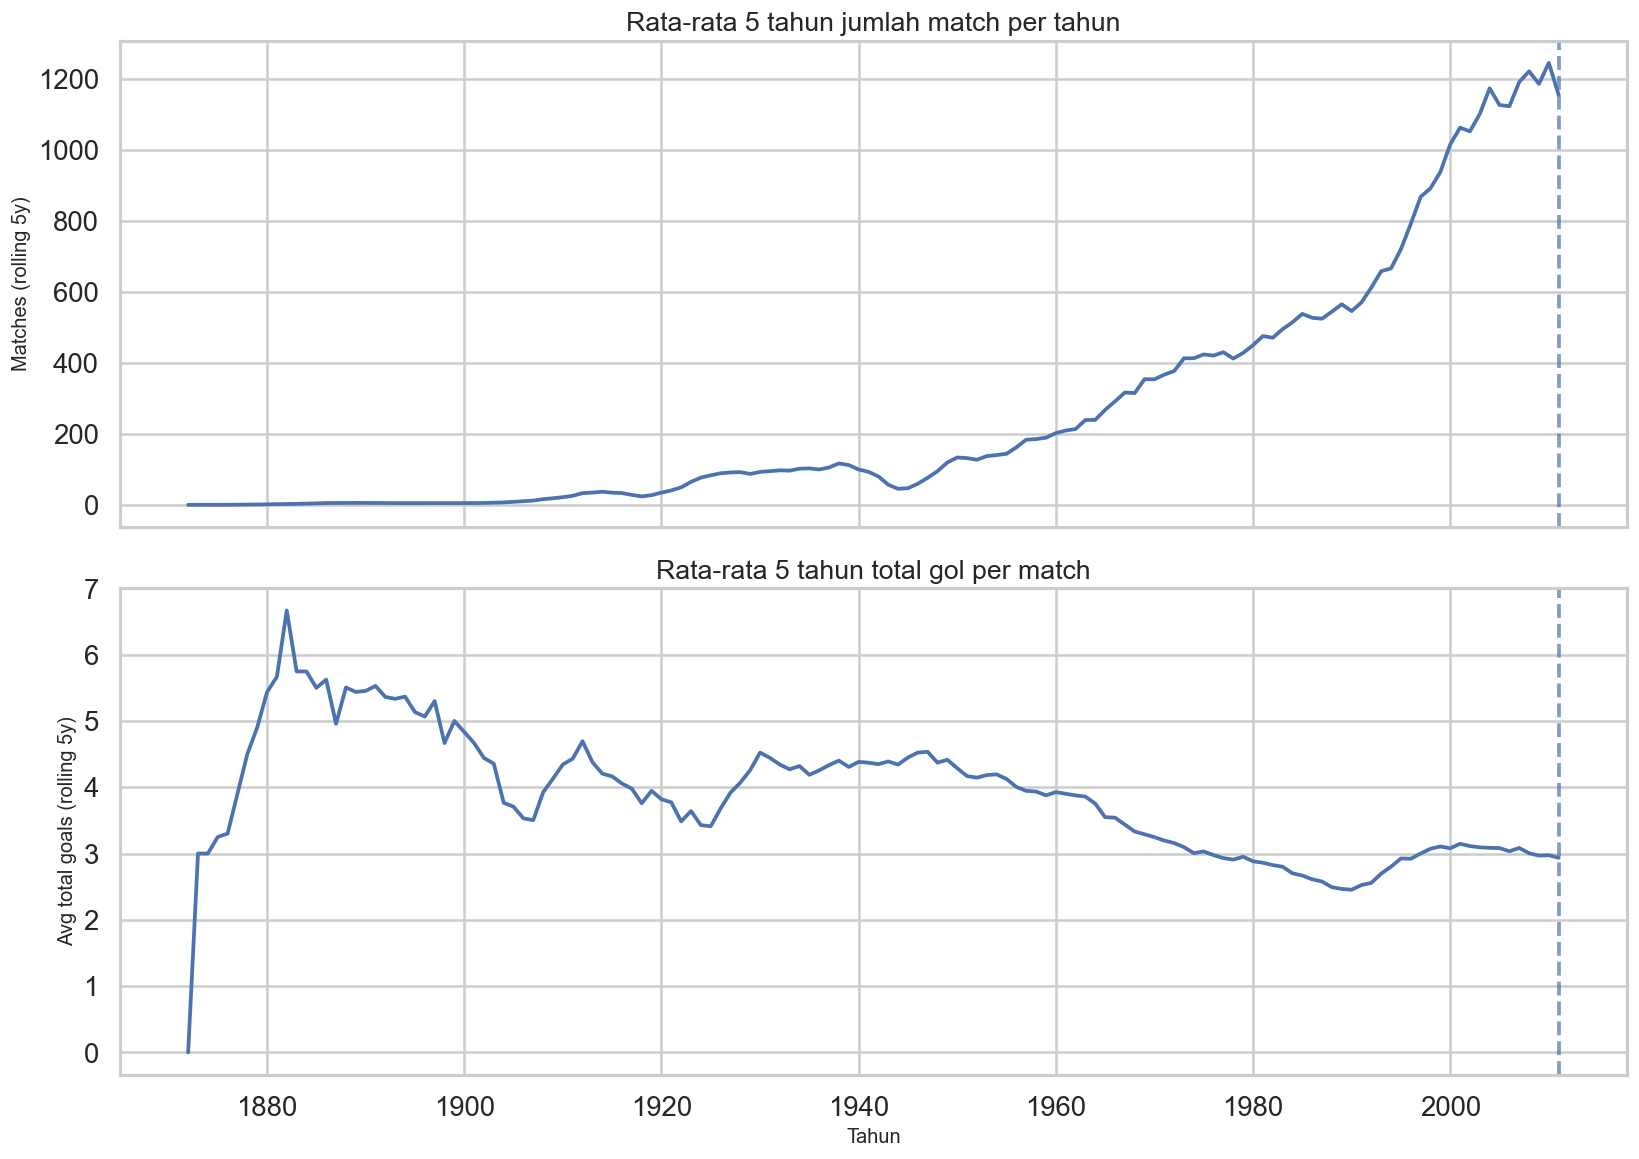

In [7]:
yearly = train_match.groupby("year").agg(
    matches=("match_id", "count"),
    avg_total_goals=("total_goals", "mean"),
).reset_index()

yearly["matches_roll5"] = yearly["matches"].rolling(5, min_periods=1).mean()
yearly["avg_goals_roll5"] = yearly["avg_total_goals"].rolling(5, min_periods=1).mean()

fig, ax = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

ax[0].plot(yearly["year"], yearly["matches_roll5"])
ax[0].set_title("Rata-rata 5 tahun jumlah match per tahun")
ax[0].set_ylabel("Matches (rolling 5y)")

ax[1].plot(yearly["year"], yearly["avg_goals_roll5"])
ax[1].set_title("Rata-rata 5 tahun total gol per match")
ax[1].set_ylabel("Avg total goals (rolling 5y)")
ax[1].set_xlabel("Tahun")

for a in ax:
    a.axvline(train["date"].max().year, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

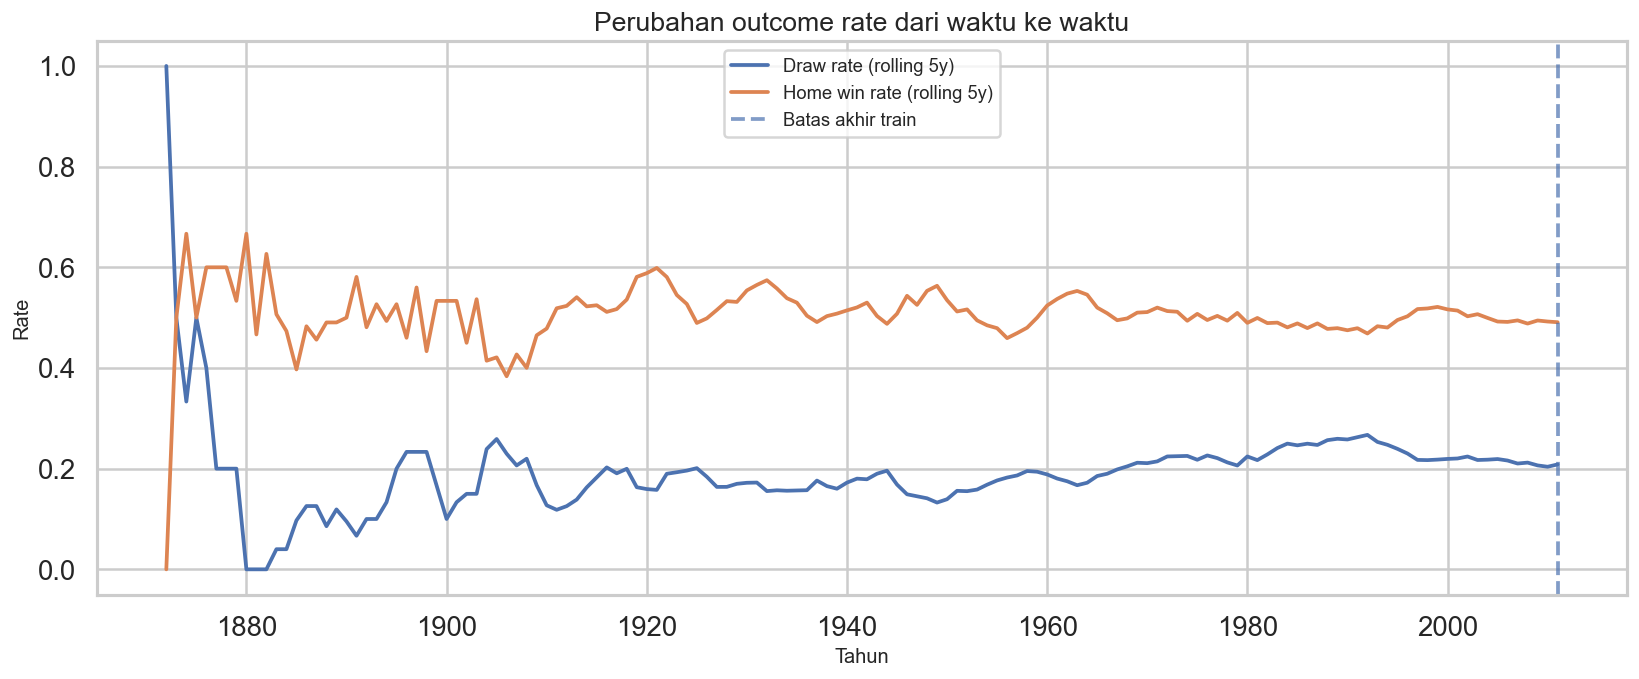

**Insight cepat:**

- Train mencakup periode **1872-11-30** sampai **2011-08-04**
- Test dimulai **2011-08-06**
- Karena distribusi pertandingan berubah cukup panjang antar-era, validasi nanti **harus time-based**, bukan random split.

In [8]:
yearly_outcome = train_match.groupby("year").agg(
    draw_rate=("outcome", lambda s: (s == "Draw").mean()),
    home_win_rate=("outcome", lambda s: (s == "Home Win").mean()),
).reset_index()

yearly_outcome["draw_roll5"] = yearly_outcome["draw_rate"].rolling(5, min_periods=1).mean()
yearly_outcome["home_win_roll5"] = yearly_outcome["home_win_rate"].rolling(5, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(yearly_outcome["year"], yearly_outcome["draw_roll5"], label="Draw rate (rolling 5y)")
ax.plot(yearly_outcome["year"], yearly_outcome["home_win_roll5"], label="Home win rate (rolling 5y)")
ax.axvline(train["date"].max().year, linestyle="--", alpha=0.7, label="Batas akhir train")
ax.set_title("Perubahan outcome rate dari waktu ke waktu")
ax.set_xlabel("Tahun")
ax.set_ylabel("Rate")
ax.legend()
plt.tight_layout()
plt.show()

insight_lines = [
    "**Insight cepat:**",
    "",
    f"- Train mencakup periode **{train['date'].min().date()}** sampai **{train['date'].max().date()}**",
    f"- Test dimulai **{test['date'].min().date()}**",
    "- Karena distribusi pertandingan berubah cukup panjang antar-era, validasi nanti **harus time-based**, bukan random split.",
]
display(Markdown(chr(10).join(insight_lines)))

## 5. EDA train–test shift

Bagian ini sangat penting untuk kompetisi. Kita ingin tahu apakah train dan test benar-benar mirip atau justru sudah bergeser distribusinya.

In [9]:
gender_shift = compare_category_distribution(train_match["gender"], test_match["gender"], top_n=10)
neutral_shift = compare_category_distribution(train_match["neutral"].astype(str), test_match["neutral"].astype(str), top_n=10)
confed_shift = compare_category_distribution(train["confederation_team"], test["confederation_team"], top_n=10)

print("Perbandingan distribusi gender")
display(style_pct_columns(gender_shift, ["train_share", "test_share", "abs_diff"]))

print()
print("Perbandingan distribusi neutral")
display(style_pct_columns(neutral_shift, ["train_share", "test_share", "abs_diff"]))

print()
print("Perbandingan distribusi confederation_team")
display(style_pct_columns(confed_shift, ["train_share", "test_share", "abs_diff"]))

unseen_summary = pd.DataFrame({
    "column": ["team", "opponent", "tournament", "venue_country", "confederation_team", "confederation_opp"],
    "unseen_unique_in_test": [
        len(set(test["team"]) - set(train["team"])),
        len(set(test["opponent"]) - set(train["opponent"])),
        len(set(test["tournament"]) - set(train["tournament"])),
        len(set(test["venue_country"]) - set(train["venue_country"])),
        len(set(test["confederation_team"]) - set(train["confederation_team"])),
        len(set(test["confederation_opp"]) - set(train["confederation_opp"])),
    ],
    "share_test_rows_with_unseen": [
        (~test["team"].isin(set(train["team"]))).mean(),
        (~test["opponent"].isin(set(train["opponent"]))).mean(),
        (~test["tournament"].isin(set(train["tournament"]))).mean(),
        (~test["venue_country"].isin(set(train["venue_country"]))).mean(),
        (~test["confederation_team"].isin(set(train["confederation_team"]))).mean(),
        (~test["confederation_opp"].isin(set(train["confederation_opp"]))).mean(),
    ]
})
display(style_pct_columns(unseen_summary, ["share_test_rows_with_unseen"]))

Perbandingan distribusi gender


,gender,train_share,test_share,abs_diff
0,W,11.18%,32.90%,21.72%
1,M,88.82%,67.10%,21.72%



Perbandingan distribusi neutral


,neutral,train_share,test_share,abs_diff
0,0,73.10%,66.98%,6.12%
1,1,26.90%,33.02%,6.12%



Perbandingan distribusi confederation_team


,confederation_team,train_share,test_share,abs_diff
0,CONMEBOL,8.03%,5.77%,2.26%
1,AFC,19.35%,20.82%,1.47%
2,CAF,18.41%,19.45%,1.04%
3,Unknown,8.13%,7.37%,0.76%
4,CONCACAF,9.80%,10.53%,0.74%
5,UEFA,34.17%,33.48%,0.68%
6,OFC,2.11%,2.57%,0.46%


,column,unseen_unique_in_test,share_test_rows_with_unseen
0,team,50,1.17%
1,opponent,50,1.17%
2,tournament,87,13.87%
3,venue_country,7,0.57%
4,confederation_team,0,0.00%
5,confederation_opp,0,0.00%


,feature,train_median,test_median,ks_stat,p_value
3,gdp_per_capita_team,2.818914e+03,8.329271e+03,0.275589,0.000000e+00
4,gdp_per_capita_opp,2.818914e+03,8.329271e+03,0.275589,0.000000e+00
2,distance_travel_opp,5.996346e+02,1.016550e+03,0.070494,1.669865e-72
1,distance_travel_team,5.996346e+02,1.016550e+03,0.070494,1.669865e-72
6,population_opp,9.820481e+06,1.052380e+07,0.063431,3.163599e-85
5,population_team,9.820481e+06,1.052380e+07,0.063431,3.163599e-85
0,altitude_venue_clean,1.235000e+02,1.330000e+02,0.060746,2.493045e-65
7,temperature_venue,1.968051e+01,1.963994e+01,0.050857,2.794881e-52


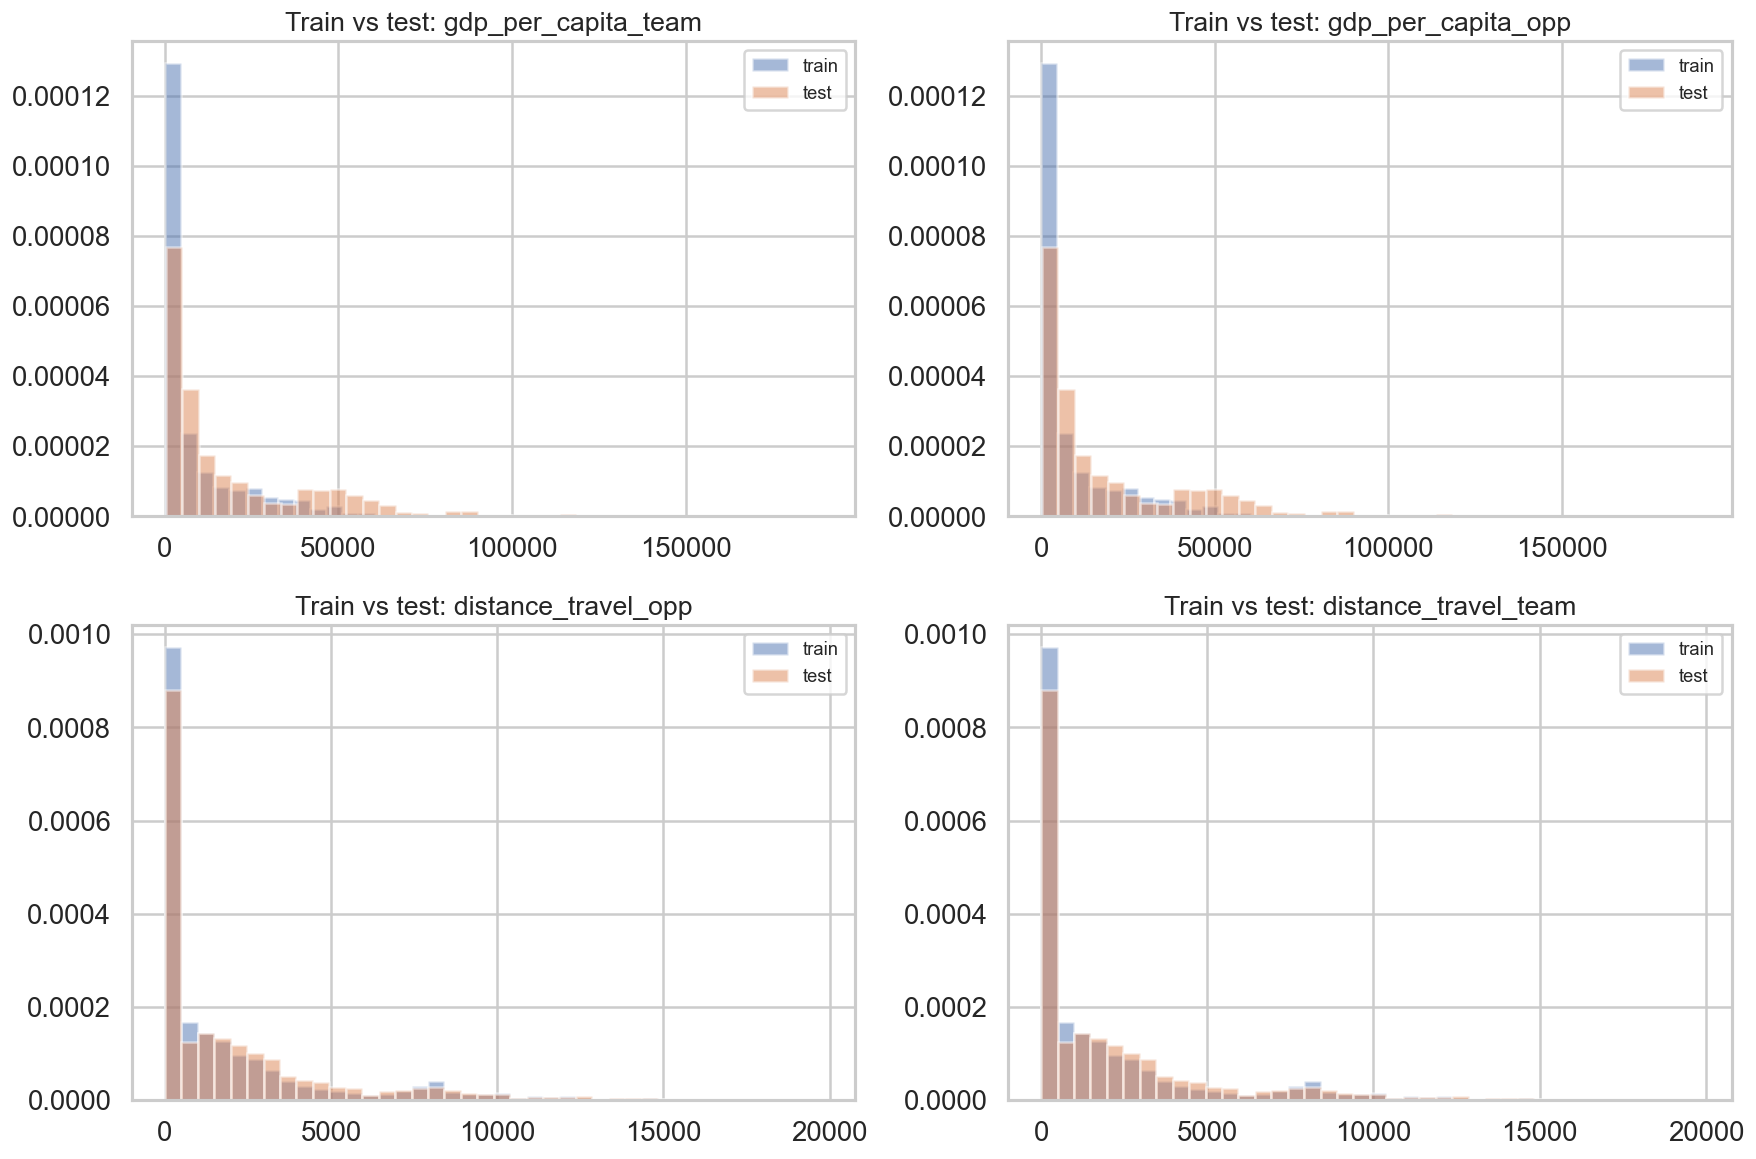

In [10]:
numeric_common = [
    "altitude_venue_clean",
    "distance_travel_team",
    "distance_travel_opp",
    "gdp_per_capita_team",
    "gdp_per_capita_opp",
    "population_team",
    "population_opp",
    "temperature_venue",
]

drift_rows = []
for col in numeric_common:
    a = train[col].dropna()
    b = test[col].dropna()
    ks_stat = np.nan
    p_value = np.nan
    if ks_2samp is not None and len(a) > 0 and len(b) > 0:
        ks_stat, p_value = ks_2samp(a, b)
    drift_rows.append({
        "feature": col,
        "train_median": a.median() if len(a) else np.nan,
        "test_median": b.median() if len(b) else np.nan,
        "ks_stat": ks_stat,
        "p_value": p_value,
    })

drift_df = pd.DataFrame(drift_rows).sort_values("ks_stat", ascending=False)
display(drift_df)

top_drift_features = drift_df["feature"].head(4).tolist()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for ax, col in zip(axes, top_drift_features):
    ax.hist(train[col].dropna(), bins=40, density=True, alpha=0.5, label="train")
    ax.hist(test[col].dropna(), bins=40, density=True, alpha=0.5, label="test")
    ax.set_title(f"Train vs test: {col}")
    ax.legend()

plt.tight_layout()
plt.show()

## 6. EDA berdasarkan gender

Kita cek apakah pertandingan `M` dan `W` punya karakter skor yang berbeda. Ini penting karena pergeseran gender train–test cukup besar.

,gender,matches,avg_home_goals,avg_away_goals,avg_total_goals,median_total_goals,draw_rate,home_win_rate,high_scoring_share
0,M,34983,1.815339,1.207329,3.022668,3.0,22.59%,49.45%,11.13%
1,W,4403,2.471724,1.477402,3.949126,3.0,13.04%,54.89%,21.33%


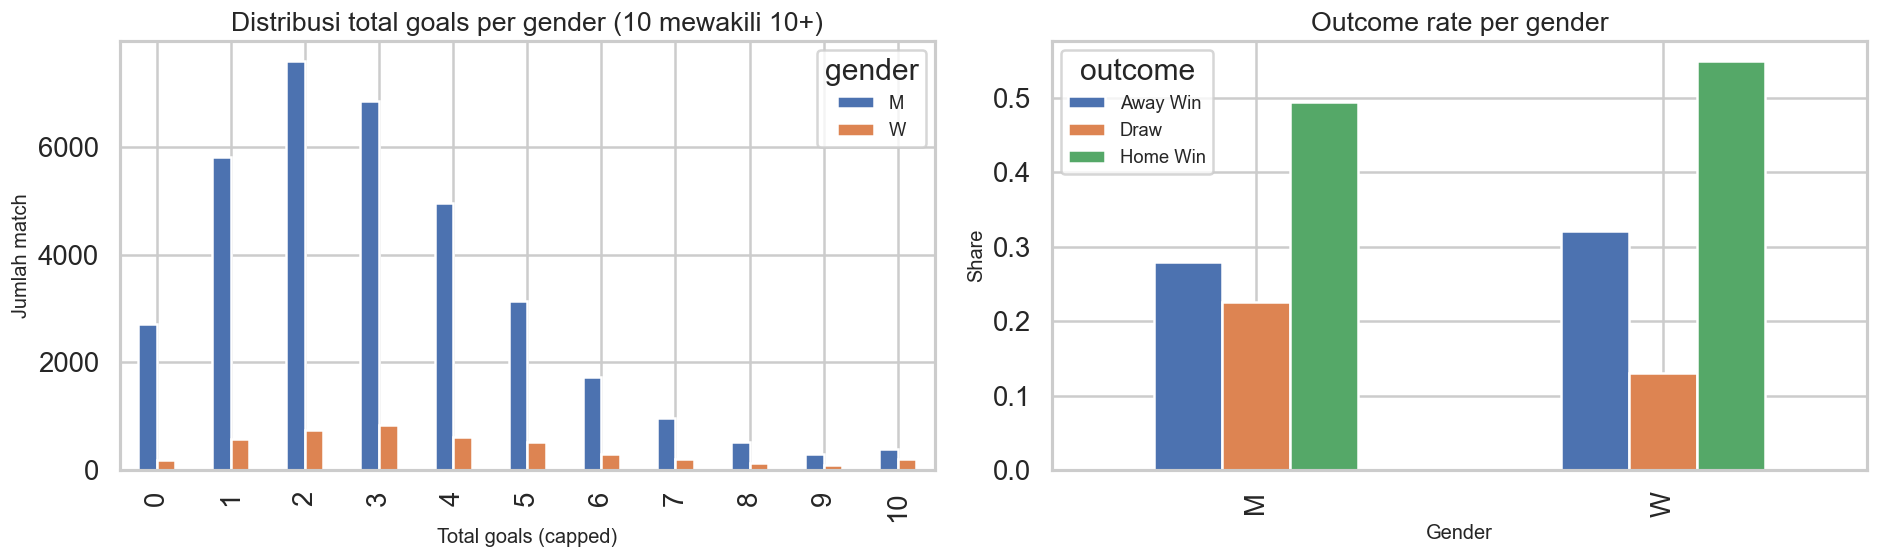

In [11]:
gender_stats = train_match.groupby("gender").agg(
    matches=("match_id", "count"),
    avg_home_goals=("home_goals", "mean"),
    avg_away_goals=("away_goals", "mean"),
    avg_total_goals=("total_goals", "mean"),
    median_total_goals=("total_goals", "median"),
    draw_rate=("outcome", lambda s: (s == "Draw").mean()),
    home_win_rate=("outcome", lambda s: (s == "Home Win").mean()),
    high_scoring_share=("total_goals", lambda s: (s >= 6).mean()),
).reset_index()

display(style_pct_columns(gender_stats, ["draw_rate", "home_win_rate", "high_scoring_share"]))

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

gender_goal_dist = (
    train_match.assign(total_goals_cap=train_match["total_goals"].clip(upper=10))
    .groupby(["gender", "total_goals_cap"]).size()
    .unstack(fill_value=0)
    .T
)
gender_goal_dist.plot(kind="bar", ax=ax[0])
ax[0].set_title("Distribusi total goals per gender (10 mewakili 10+)")
ax[0].set_xlabel("Total goals (capped)")
ax[0].set_ylabel("Jumlah match")

outcome_pivot = pd.crosstab(train_match["gender"], train_match["outcome"], normalize="index")
outcome_pivot.plot(kind="bar", ax=ax[1])
ax[1].set_title("Outcome rate per gender")
ax[1].set_xlabel("Gender")
ax[1].set_ylabel("Share")

plt.tight_layout()
plt.show()

## 7. EDA berdasarkan tournament

Tournament sering membawa karakter pertandingan yang berbeda. Ada yang lebih terbuka, ada yang lebih ketat, ada juga yang sample-nya besar sekali.

Top 15 tournament berdasarkan jumlah match


,matches,avg_total_goals,draw_rate,home_win_rate
tournament,,,,
Friendly,14003,2.976434,0.247804,0.468971
FIFA World Cup qualification,5967,3.026814,0.199598,0.522373
UEFA Euro qualification,2849,3.074061,0.190242,0.482625
African Cup of Nations qualification,1367,2.468178,0.245062,0.577176
FIFA World Cup,952,2.975840,0.206933,0.478992
Copa América,830,3.485542,0.191566,0.536145
AFC Asian Cup qualification,632,3.545886,0.151899,0.609177
Merdeka Tournament,595,3.285714,0.213445,0.478992
British Home Championship,523,3.516252,0.208413,0.451243


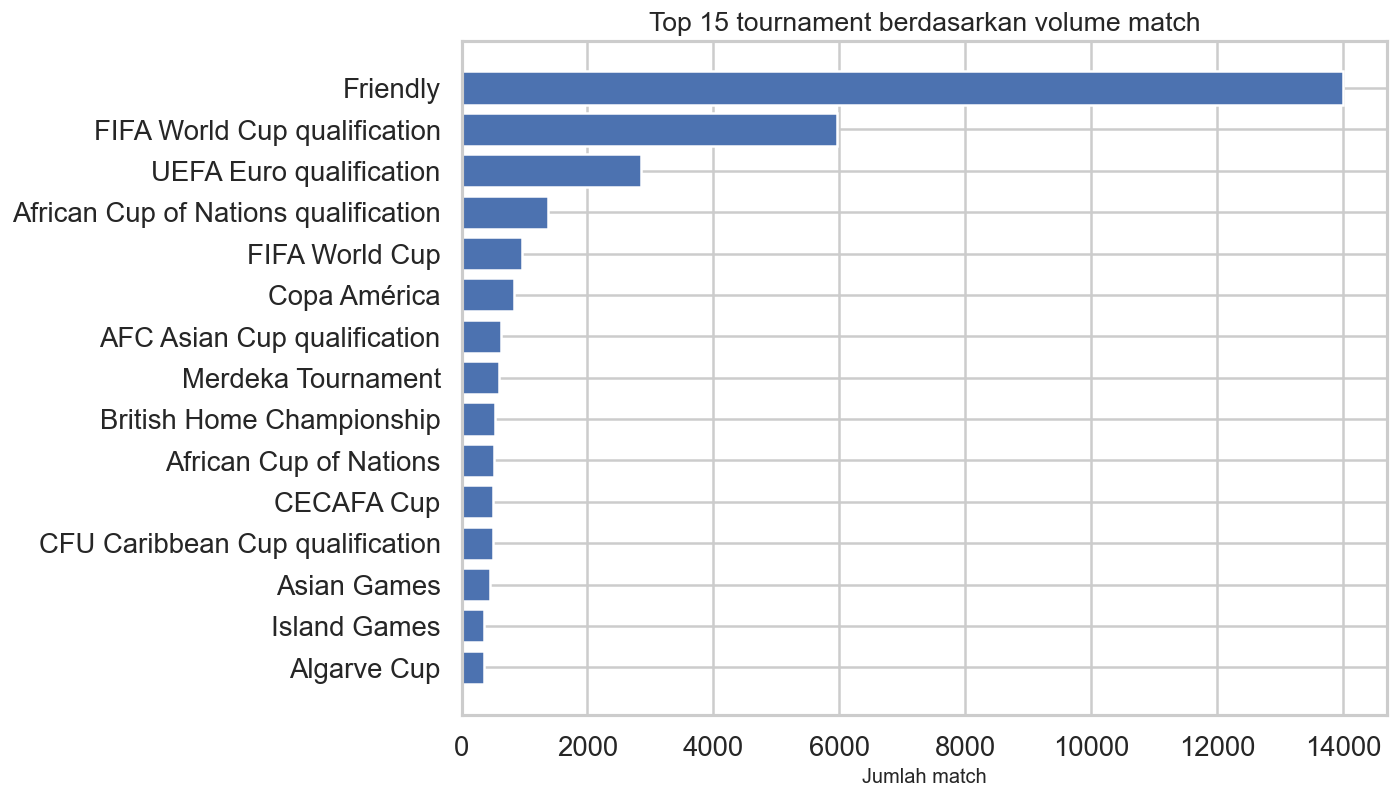

Tournament paling high-scoring (minimal 100 match)


,matches,avg_total_goals,draw_rate,home_win_rate
tournament,,,,
South Pacific Games,205,5.912195,0.112195,0.531707
AFC Championship,253,5.304348,0.055336,0.750988
CONCACAF Gold Cup qualification,119,4.722689,0.050420,0.722689
CCCF Championship,123,4.463415,0.138211,0.585366
Muratti Vase,200,4.450000,0.065000,0.560000
Island Games,359,4.264624,0.100279,0.576602
Central European International Cup,126,4.190476,0.230159,0.539683
AFF Championship,209,3.990431,0.177033,0.593301
African Championship qualification,133,3.969925,0.195489,0.443609


In [12]:
tournament_stats = train_match.groupby("tournament").agg(
    matches=("match_id", "count"),
    avg_total_goals=("total_goals", "mean"),
    draw_rate=("outcome", lambda s: (s == "Draw").mean()),
    home_win_rate=("outcome", lambda s: (s == "Home Win").mean()),
).sort_values("matches", ascending=False)

print("Top 15 tournament berdasarkan jumlah match")
display(tournament_stats.head(15))

fig, ax = plt.subplots(figsize=(12, 7))
plot_df = tournament_stats.head(15).sort_values("matches")
ax.barh(plot_df.index, plot_df["matches"])
ax.set_title("Top 15 tournament berdasarkan volume match")
ax.set_xlabel("Jumlah match")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

high_volume_high_scoring = tournament_stats[tournament_stats["matches"] >= 100].sort_values("avg_total_goals", ascending=False).head(15)
print("Tournament paling high-scoring (minimal 100 match)")
display(high_volume_high_scoring)

## 8. EDA home / neutral

Karena sepak bola sering dipengaruhi home advantage, kita cek apakah status `neutral` mengubah pola hasil pertandingan.

,neutral,matches,avg_total_goals,draw_rate,home_win_rate,away_win_rate
0,0,28790,3.056408,22.15%,50.76%,27.09%
1,1,10596,3.315968,19.81%,48.14%,32.05%


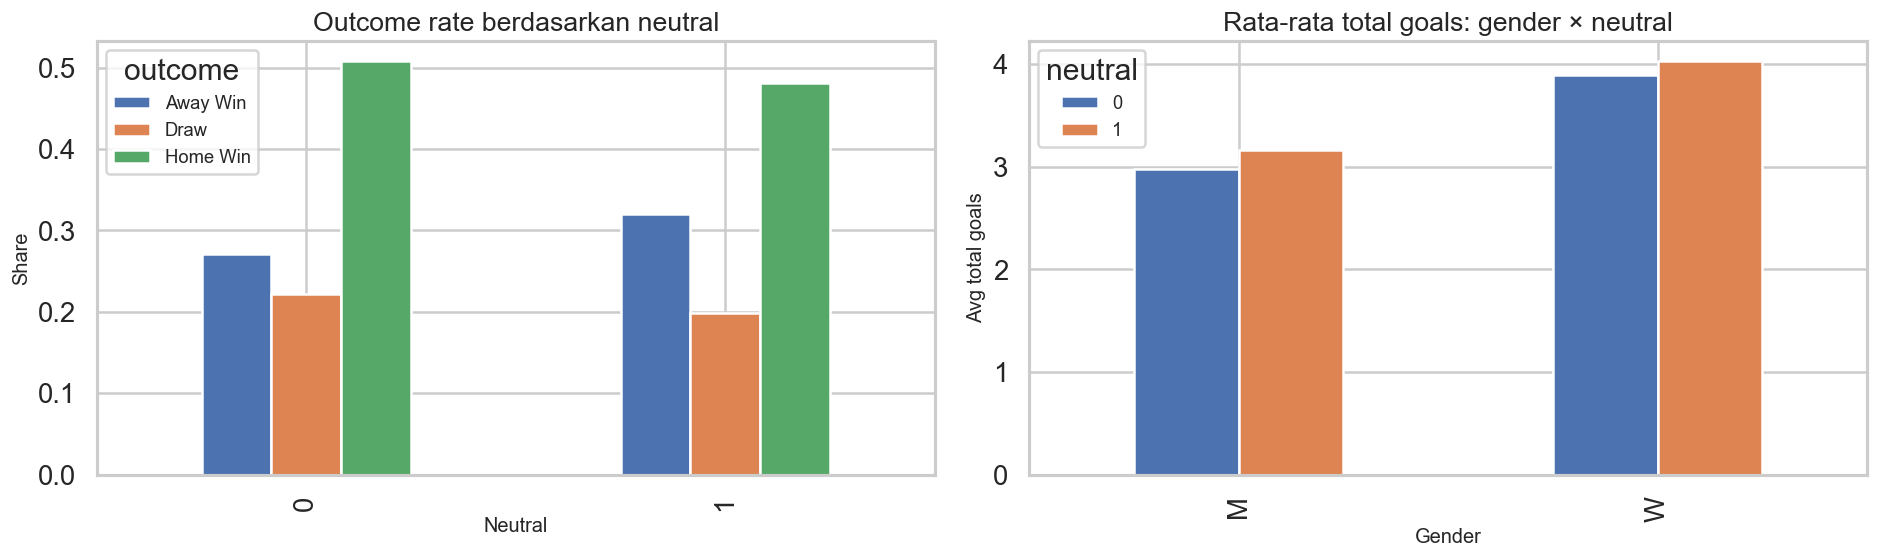

In [13]:
neutral_stats = train_match.groupby("neutral").agg(
    matches=("match_id", "count"),
    avg_total_goals=("total_goals", "mean"),
    draw_rate=("outcome", lambda s: (s == "Draw").mean()),
    home_win_rate=("outcome", lambda s: (s == "Home Win").mean()),
    away_win_rate=("outcome", lambda s: (s == "Away Win").mean()),
).reset_index()

display(style_pct_columns(neutral_stats, ["draw_rate", "home_win_rate", "away_win_rate"]))

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

outcome_pivot = pd.crosstab(train_match["neutral"], train_match["outcome"], normalize="index")
outcome_pivot.plot(kind="bar", ax=ax[0])
ax[0].set_title("Outcome rate berdasarkan neutral")
ax[0].set_xlabel("Neutral")
ax[0].set_ylabel("Share")

goals_gender_neutral = (
    train_match.groupby(["gender", "neutral"])["total_goals"]
    .mean()
    .unstack(fill_value=0)
)
goals_gender_neutral.plot(kind="bar", ax=ax[1])
ax[1].set_title("Rata-rata total goals: gender × neutral")
ax[1].set_xlabel("Gender")
ax[1].set_ylabel("Avg total goals")

plt.tight_layout()
plt.show()

## 9. EDA missing values dan kualitas data

Di bagian ini kita lihat:

- kolom mana yang banyak missing,
- apakah missing sama antara train dan test,
- apakah ada sentinel value yang harus dianggap invalid,
- dan apakah missing berubah antar-era.

,column,train_missing_rate,test_missing_rate
0,rank_diff,55.73%,NaN
1,rank_team,53.25%,NaN
2,rank_opponent,53.25%,NaN
3,distance_travel_opp,38.58%,40.01%
4,distance_travel_team,38.58%,40.01%
5,gdp_per_capita_opp,32.95%,34.57%
6,gdp_per_capita_team,32.95%,34.57%
7,altitude_venue,26.09%,25.71%
8,temperature_venue,21.68%,13.19%
9,population_team,18.88%,7.95%


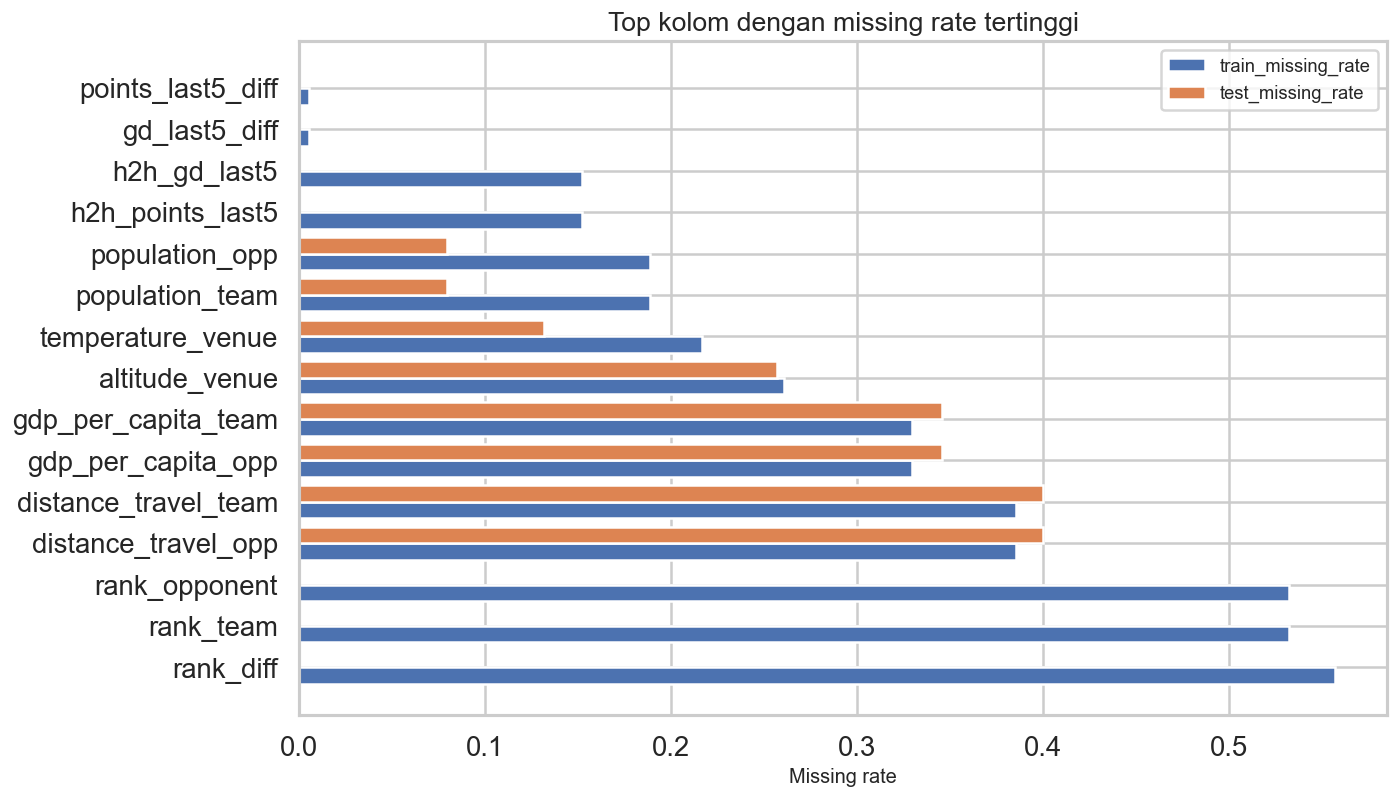

,dataset,altitude_eq_-9999,share_rows
0,train,766,0.97%
1,test,296,0.70%


In [14]:
missing_train = train[original_train_cols].isna().mean().rename("train_missing_rate")
missing_test = test[original_test_cols].isna().mean().rename("test_missing_rate")

missing_compare = pd.concat([missing_train, missing_test], axis=1).sort_values("train_missing_rate", ascending=False)
display(style_pct_columns(missing_compare.reset_index().rename(columns={"index": "column"}), ["train_missing_rate", "test_missing_rate"]))

top_missing = missing_compare.head(15).reset_index().rename(columns={"index": "column"})

fig, ax = plt.subplots(figsize=(12, 7))
bar_h = 0.4
y = np.arange(len(top_missing))
ax.barh(y - bar_h/2, top_missing["train_missing_rate"], height=bar_h, label="train_missing_rate")
ax.barh(y + bar_h/2, top_missing["test_missing_rate"].fillna(0), height=bar_h, label="test_missing_rate")
ax.set_yticks(y)
ax.set_yticklabels(top_missing["column"])
ax.set_title("Top kolom dengan missing rate tertinggi")
ax.set_xlabel("Missing rate")
ax.legend()
plt.tight_layout()
plt.show()

sentinel_summary = pd.DataFrame({
    "dataset": ["train", "test"],
    "altitude_eq_-9999": [
        (train["altitude_venue"] == -9999).sum(),
        (test["altitude_venue"] == -9999).sum(),
    ],
    "share_rows": [
        (train["altitude_venue"] == -9999).mean(),
        (test["altitude_venue"] == -9999).mean(),
    ]
})
display(style_pct_columns(sentinel_summary, ["share_rows"]))

,era,rank_team,rank_opponent,gdp_per_capita_team,population_team,altitude_venue,temperature_venue,distance_travel_team
0,<=1949,100.00%,100.00%,100.00%,100.00%,24.63%,80.71%,32.74%
1,1950-1989,100.00%,100.00%,37.32%,17.70%,28.36%,19.46%,40.52%
2,1990-2005,19.13%,19.13%,19.54%,7.03%,25.26%,14.27%,38.05%
3,2006-2011,7.91%,7.91%,20.51%,7.72%,23.93%,13.71%,38.55%


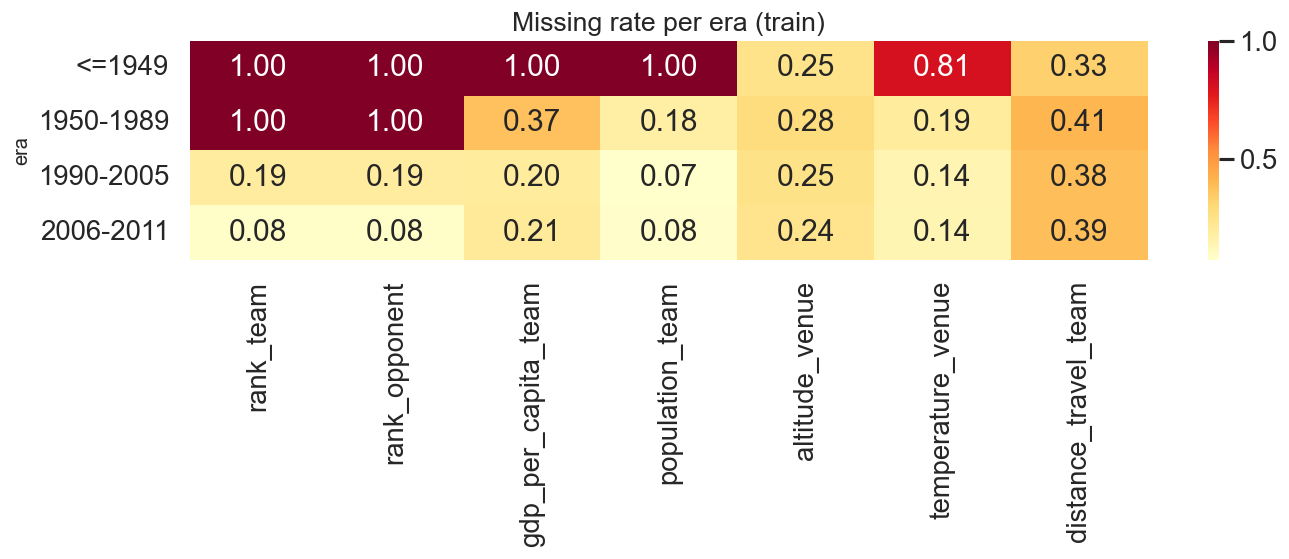

In [15]:
train["era"] = pd.cut(
    train["year"],
    bins=[1871, 1949, 1989, 2005, 2011],
    labels=["<=1949", "1950-1989", "1990-2005", "2006-2011"]
)

selected_missing_cols = [
    "rank_team", "rank_opponent", "gdp_per_capita_team", "population_team",
    "altitude_venue", "temperature_venue", "distance_travel_team"
]

missing_by_era = train.groupby("era")[selected_missing_cols].apply(lambda d: d.isna().mean())
display(style_pct_columns(missing_by_era.reset_index(), selected_missing_cols))

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(missing_by_era, annot=True, fmt=".2f", cmap="YlOrRd", ax=ax)
ax.set_title("Missing rate per era (train)")
plt.tight_layout()
plt.show()

## 10. EDA fitur common vs train-only

Bagian ini penting supaya kita tidak salah memilih fitur. Fitur train-only boleh dianalisis untuk mencari insight, tetapi **tidak bisa langsung dipakai saat inference** jika tidak tersedia di test.

,feature_group,count
0,Common columns,20
1,Train-only columns,27


,abs_corr_with_team_goals,abs_corr_with_opp_goals
opp_avg_conceded_last5,0.428901,0.000000
rank_diff,0.365901,0.365901
gd_last5_diff,0.361488,0.403657
opp_gd_last5,0.344786,0.309233
h2h_gd_last5,0.333771,0.333771
points_last5_diff,0.300410,0.323225
opp_points_last5,0.286238,0.247611
elo_opponent,0.280602,0.000000
opp_points_last10,0.279083,0.000000
rank_opponent,0.237578,0.000000


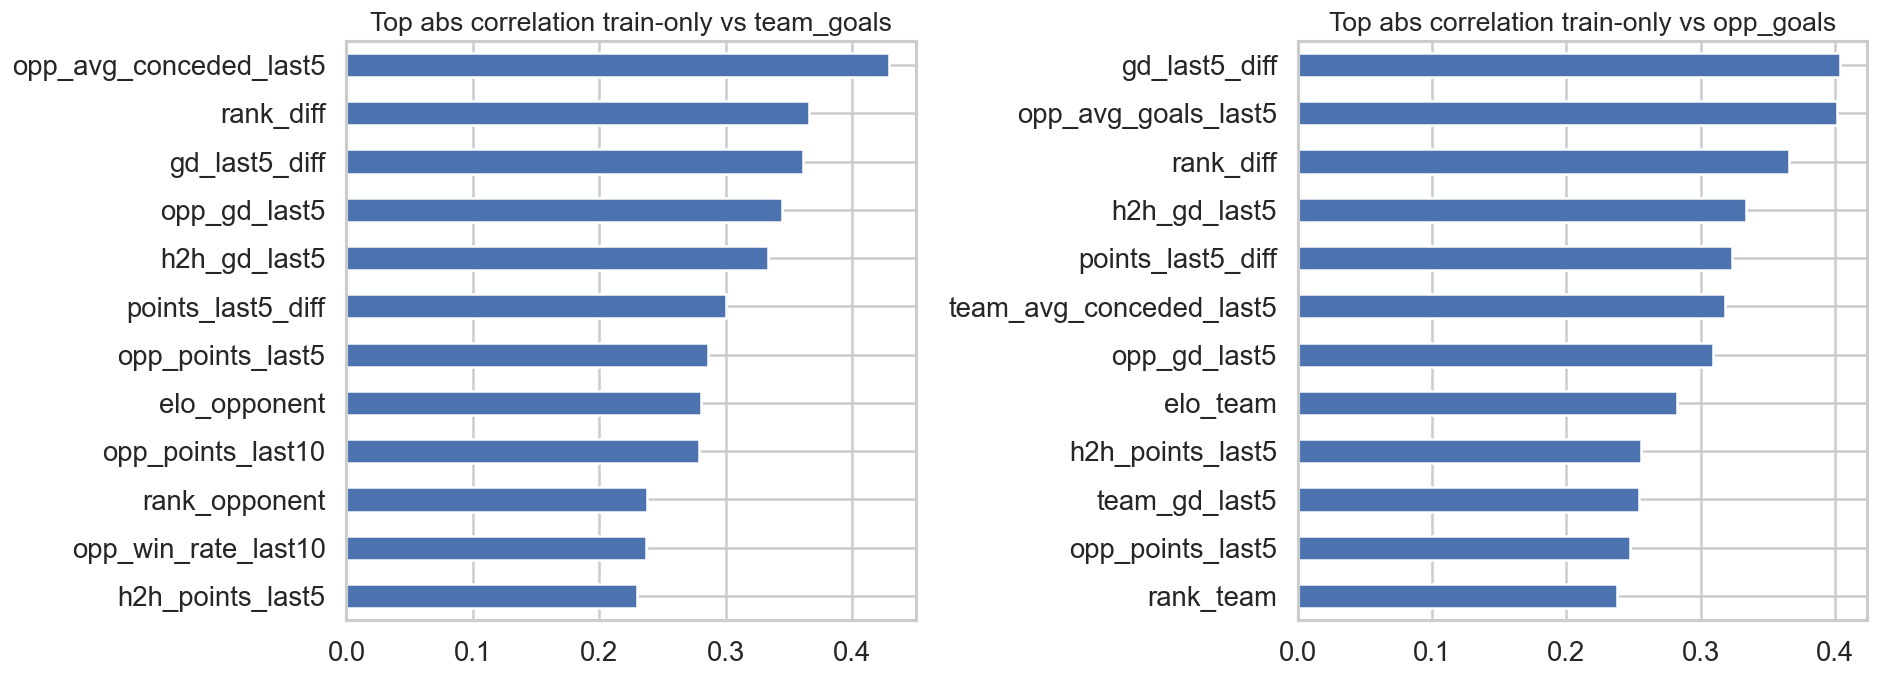

In [16]:
summary_feature_groups = pd.DataFrame({
    "feature_group": ["Common columns", "Train-only columns"],
    "count": [len(common_cols), len(train_only_cols)],
})
display(summary_feature_groups)

numeric_train_only = [
    c for c in train_only_cols
    if pd.api.types.is_numeric_dtype(train[c]) and c not in ["team_goals", "opp_goals"]
]

corr_team = (
    train[numeric_train_only + ["team_goals"]]
    .corr(numeric_only=True)["team_goals"]
    .drop("team_goals")
    .abs()
    .sort_values(ascending=False)
    .head(12)
)

corr_opp = (
    train[numeric_train_only + ["opp_goals"]]
    .corr(numeric_only=True)["opp_goals"]
    .drop("opp_goals")
    .abs()
    .sort_values(ascending=False)
    .head(12)
)

corr_compare = pd.concat([
    corr_team.rename("abs_corr_with_team_goals"),
    corr_opp.rename("abs_corr_with_opp_goals")
], axis=1).fillna(0)
display(corr_compare)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
corr_team.sort_values().plot(kind="barh", ax=ax[0])
ax[0].set_title("Top abs correlation train-only vs team_goals")

corr_opp.sort_values().plot(kind="barh", ax=ax[1])
ax[1].set_title("Top abs correlation train-only vs opp_goals")

plt.tight_layout()
plt.show()

## 11. EDA hubungan fitur dengan target

Di sini kita fokus ke fitur yang memang tersedia di train dan test, lalu melihat apakah ada hubungan yang terlihat dengan target.

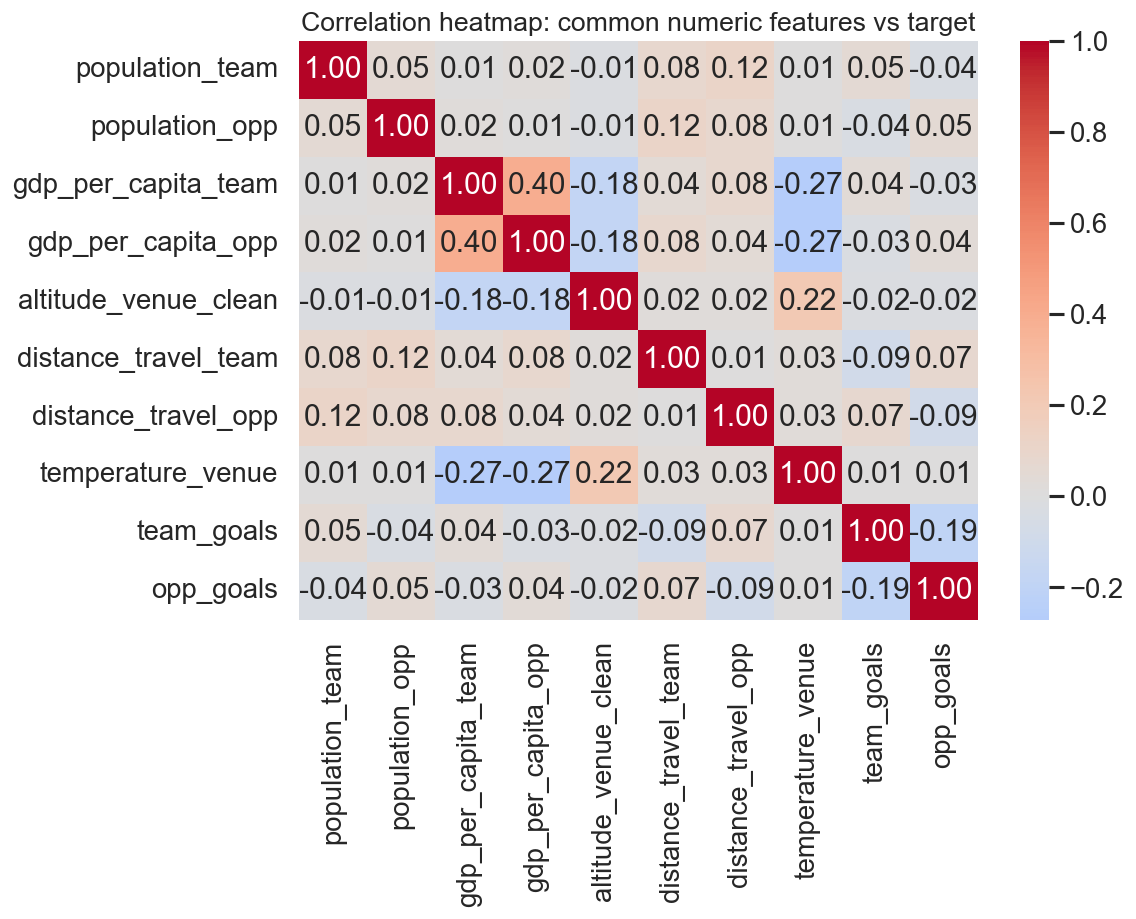

In [17]:
common_numeric_for_target = [
    "population_team", "population_opp",
    "gdp_per_capita_team", "gdp_per_capita_opp",
    "altitude_venue_clean", "distance_travel_team", "distance_travel_opp",
    "temperature_venue"
]

corr_df = train[common_numeric_for_target + ["team_goals", "opp_goals"]].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation heatmap: common numeric features vs target")
plt.tight_layout()
plt.show()

In [39]:
df = train.copy()

targets = ['team_goals', 'opp_goals']

# deteksi fitur kategorikal
cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
cat_cols = [c for c in cat_cols if c not in targets and c not in ["Id", "match_id"]]

print("Jumlah fitur kategorikal:", len(cat_cols))
print(cat_cols)

Jumlah fitur kategorikal: 8
['gender', 'team', 'opponent', 'tournament', 'venue_country', 'confederation_team', 'confederation_opp', 'era']


In [41]:
def eta_squared(cat_series, y_series):
    """
    Effect size untuk categorical feature vs numeric target.
    Nilai makin besar -> kategori makin menjelaskan variasi target.
    """
    temp = pd.DataFrame({
        'cat': cat_series,
        'y': y_series
    }).copy()

    temp = temp.dropna(subset=['y'])
    temp['cat'] = temp['cat'].astype(str).fillna('__MISSING__')

    overall_mean = temp['y'].mean()
    ss_total = ((temp['y'] - overall_mean) ** 2).sum()

    if ss_total == 0:
        return np.nan

    grouped = temp.groupby('cat')['y'].agg(['count', 'mean'])
    ss_between = (grouped['count'] * (grouped['mean'] - overall_mean) ** 2).sum()

    return ss_between / ss_total

In [42]:
rows = []

for col in cat_cols:
    row = {
        'feature': col,
        'n_unique': df[col].nunique(dropna=True),
        'missing_rate': df[col].isna().mean()
    }

    for target in targets:
        row[f'eta2_{target}'] = eta_squared(df[col], df[target])

    rows.append(row)

cat_target_df = pd.DataFrame(rows)

cat_target_team = cat_target_df.sort_values(f'eta2_team_goals', ascending=False).reset_index(drop=True)
cat_target_opp  = cat_target_df.sort_values(f'eta2_opp_goals', ascending=False).reset_index(drop=True)

print("Ranking fitur kategorikal terhadap team_goals")
display(cat_target_team)

print("Ranking fitur kategorikal terhadap opp_goals")
display(cat_target_opp)

Ranking fitur kategorikal terhadap team_goals


,feature,n_unique,missing_rate,eta2_team_goals,eta2_opp_goals
0,opponent,294,0.0,0.119933,0.055683
1,team,294,0.0,0.055683,0.119933
2,tournament,186,0.0,0.023882,0.023882
3,venue_country,268,0.0,0.019899,0.019899
4,era,4,0.0,0.008979,0.008979
5,confederation_opp,7,0.0,0.007900,0.005916
6,gender,2,0.0,0.006634,0.006634
7,confederation_team,7,0.0,0.005916,0.007900


Ranking fitur kategorikal terhadap opp_goals


,feature,n_unique,missing_rate,eta2_team_goals,eta2_opp_goals
0,team,294,0.0,0.055683,0.119933
1,opponent,294,0.0,0.119933,0.055683
2,tournament,186,0.0,0.023882,0.023882
3,venue_country,268,0.0,0.019899,0.019899
4,era,4,0.0,0.008979,0.008979
5,confederation_team,7,0.0,0.005916,0.007900
6,gender,2,0.0,0.006634,0.006634
7,confederation_opp,7,0.0,0.007900,0.005916


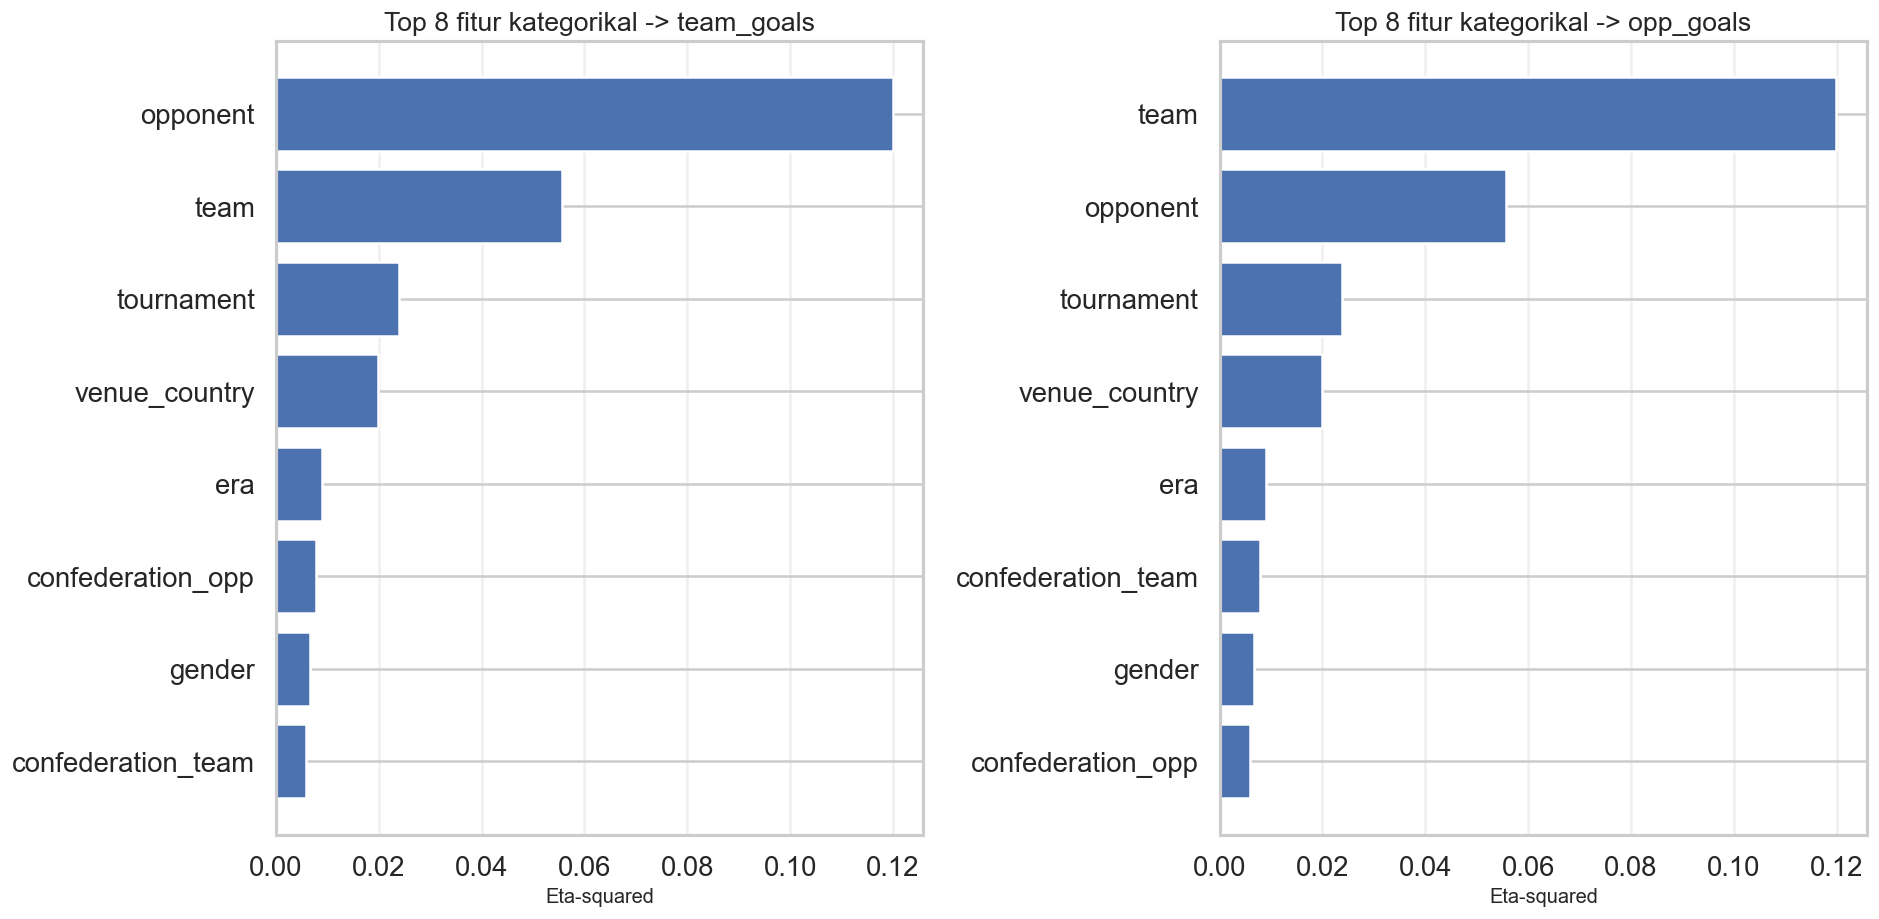

In [43]:
top_n = min(20, len(cat_target_df))

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

plot_team = cat_target_team.head(top_n).sort_values('eta2_team_goals')
plot_opp  = cat_target_opp.head(top_n).sort_values('eta2_opp_goals')

axes[0].barh(plot_team['feature'], plot_team['eta2_team_goals'])
axes[0].set_title(f'Top {top_n} fitur kategorikal -> team_goals')
axes[0].set_xlabel('Eta-squared')
axes[0].grid(axis='x', alpha=0.3)

axes[1].barh(plot_opp['feature'], plot_opp['eta2_opp_goals'])
axes[1].set_title(f'Top {top_n} fitur kategorikal -> opp_goals')
axes[1].set_xlabel('Eta-squared')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [44]:
def category_target_summary(df, cat_col, target, min_count=30, top_n=30, sort_by='mean'):
    temp = df[[cat_col, target]].copy()
    temp[cat_col] = temp[cat_col].astype(str).fillna('__MISSING__')

    summary = (
        temp.groupby(cat_col)[target]
        .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
        .reset_index()
    )

    summary = summary[summary['count'] >= min_count].copy()

    if sort_by == 'mean':
        summary = summary.sort_values('mean', ascending=False)
    elif sort_by == 'count':
        summary = summary.sort_values('count', ascending=False)

    return summary.head(top_n)

In [45]:
display(category_target_summary(train, 'tournament', 'team_goals', min_count=100, top_n=20))
display(category_target_summary(train, 'tournament', 'opp_goals', min_count=100, top_n=20))

,tournament,count,mean,median,std,min,max
133,OFC Championship,144,3.222222,1.0,4.791374,0,21
157,South Pacific Games,410,2.956098,2.0,4.216399,0,30
5,AFC Championship,506,2.652174,1.0,3.991273,0,24
50,Central American and Caribbean Games,156,2.538462,2.0,2.586278,0,14
38,CONCACAF Gold Cup,108,2.435185,1.5,3.115452,0,14
39,CONCACAF Gold Cup qualification,238,2.361345,2.0,2.696242,0,13
82,EAFF Championship,182,2.351648,1.0,3.647064,0,21
32,CCCF Championship,246,2.231707,2.0,2.030173,0,10
126,Muratti Vase,400,2.225000,2.0,2.413283,0,18
135,Oceania Nations Cup,190,2.205263,1.0,2.784115,0,17


,tournament,count,mean,median,std,min,max
133,OFC Championship,144,3.222222,1.0,4.791374,0,21
157,South Pacific Games,410,2.956098,2.0,4.216399,0,30
5,AFC Championship,506,2.652174,1.0,3.991273,0,24
50,Central American and Caribbean Games,156,2.538462,2.0,2.586278,0,14
38,CONCACAF Gold Cup,108,2.435185,1.5,3.115452,0,14
39,CONCACAF Gold Cup qualification,238,2.361345,2.0,2.696242,0,13
82,EAFF Championship,182,2.351648,1.0,3.647064,0,21
32,CCCF Championship,246,2.231707,2.0,2.030173,0,10
126,Muratti Vase,400,2.225000,2.0,2.413283,0,18
135,Oceania Nations Cup,190,2.205263,1.0,2.784115,0,17


In [46]:
def plot_category_target_mean(df, cat_col, target, min_count=30, top_n=20):
    summary = category_target_summary(
        df=df,
        cat_col=cat_col,
        target=target,
        min_count=min_count,
        top_n=top_n,
        sort_by='mean'
    ).sort_values('mean', ascending=True)

    plt.figure(figsize=(10, max(6, len(summary) * 0.35)))
    plt.barh(summary[cat_col].astype(str), summary['mean'])
    plt.title(f'Mean {target} by {cat_col} (count >= {min_count})')
    plt.xlabel(f'Mean {target}')
    plt.ylabel(cat_col)
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

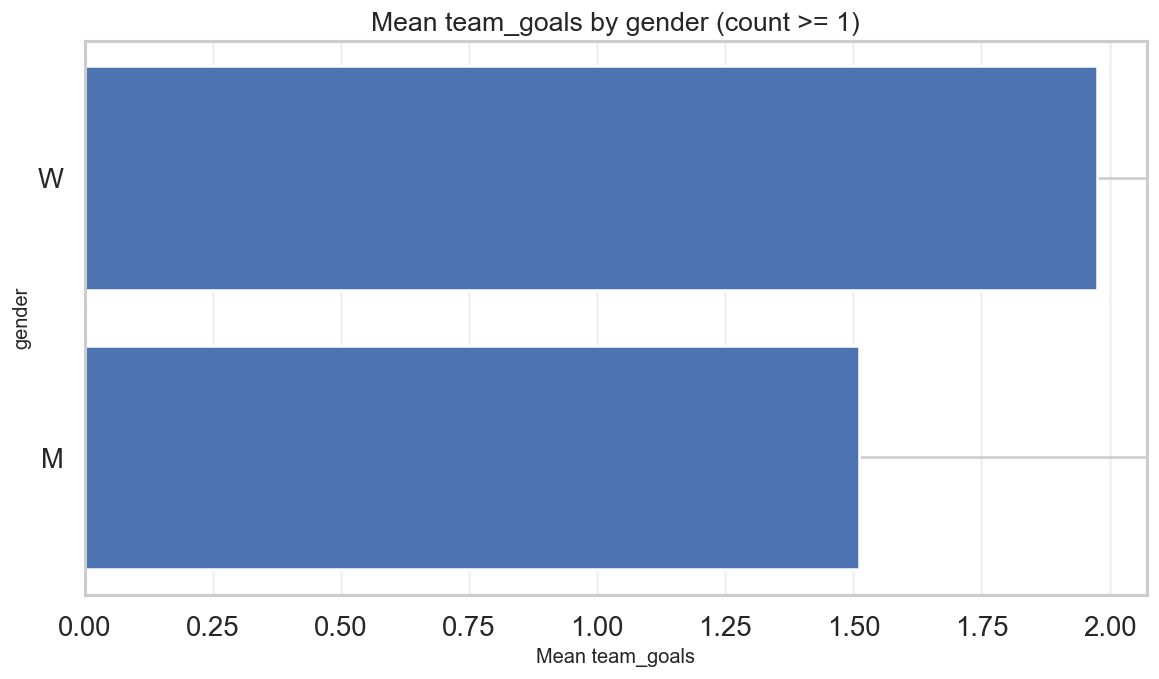

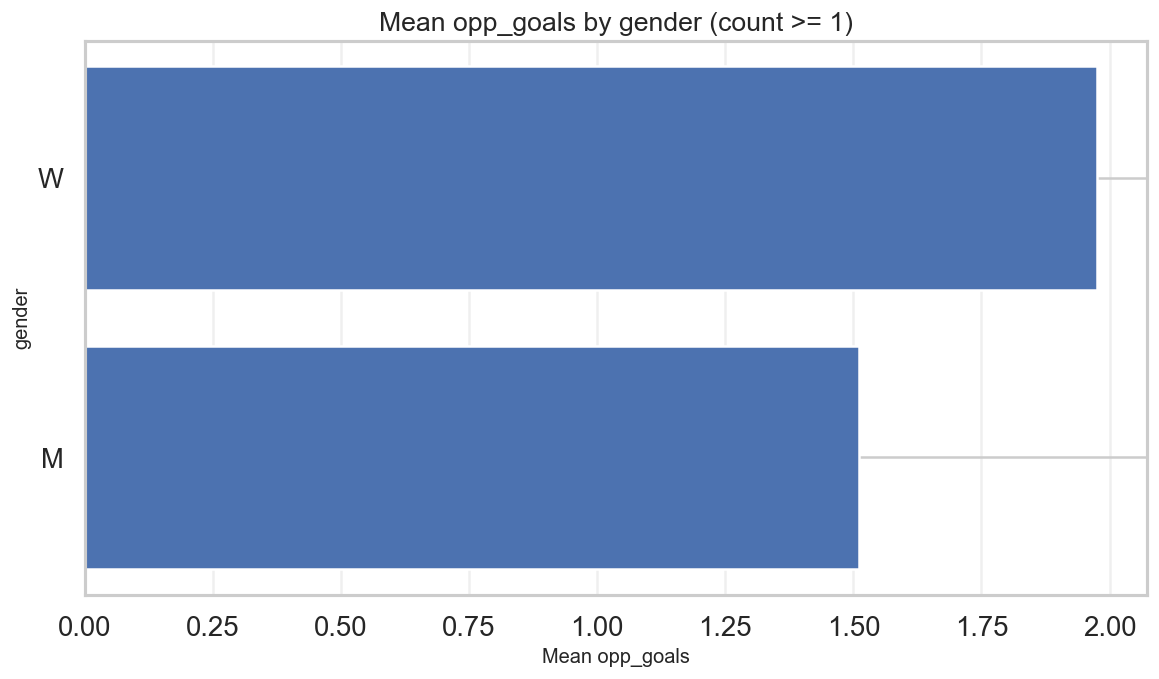

In [47]:
plot_category_target_mean(train, 'gender', 'team_goals', min_count=1, top_n=10)
plot_category_target_mean(train, 'gender', 'opp_goals', min_count=1, top_n=10)

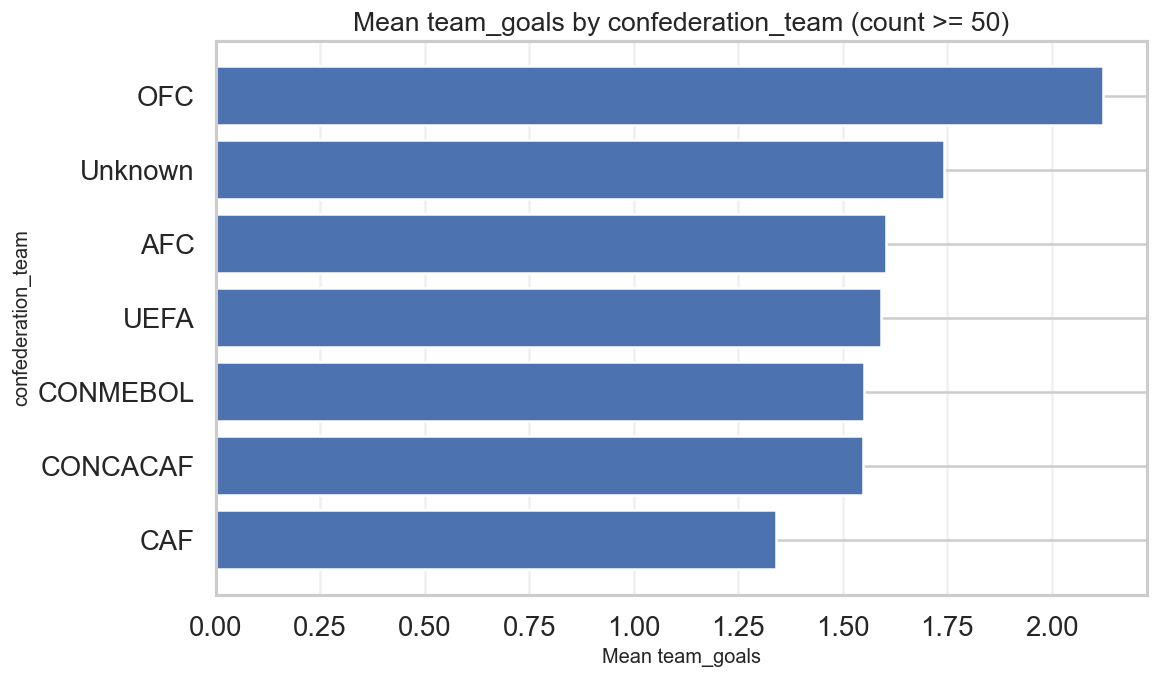

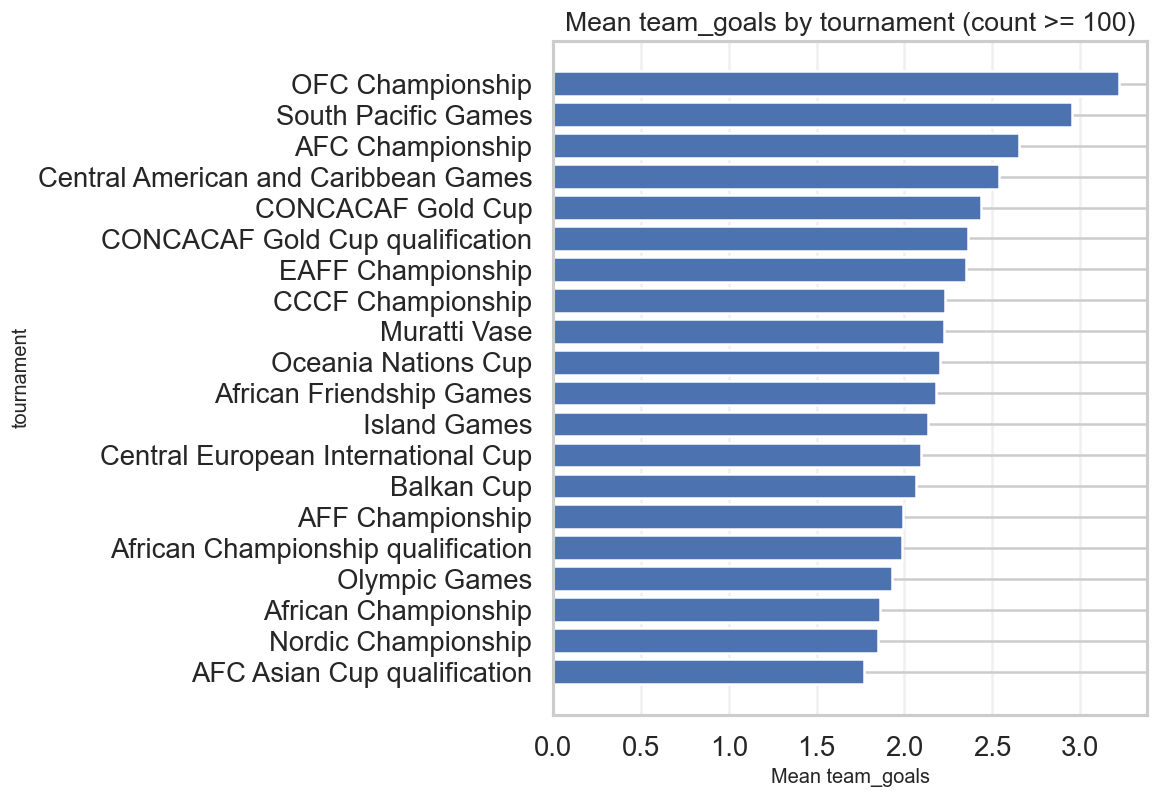

In [48]:
plot_category_target_mean(train, 'confederation_team', 'team_goals', min_count=50, top_n=20)
plot_category_target_mean(train, 'tournament', 'team_goals', min_count=100, top_n=20)

In [50]:
from sklearn.feature_selection import mutual_info_regression
import numpy as np
import pandas as pd

df_mi = train.copy()

targets = ['team_goals', 'opp_goals']

# cek dasar
print("Shape awal:", df_mi.shape)

# pastikan target numerik
for t in targets:
    df_mi[t] = pd.to_numeric(df_mi[t], errors='coerce')

# ambil kolom kategorikal
cat_cols = df_mi.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
cat_cols = [c for c in cat_cols if c not in targets and c not in ["Id", "match_id"]]

print("Jumlah fitur kategorikal:", len(cat_cols))
print(cat_cols)

mi_rows = []

for col in cat_cols:
    # ambil subset yang relevan
    temp = df_mi[[col, 'team_goals', 'opp_goals']].copy()

    # buang baris yang targetnya null
    temp = temp.dropna(subset=['team_goals', 'opp_goals'])

    # kalau habis, skip
    if len(temp) == 0:
        print(f"SKIP {col}: tidak ada sampel valid setelah dropna target")
        continue

    # isi missing kategorikal dengan aman
    temp[col] = temp[col].astype('object')
    temp[col] = temp[col].where(temp[col].notna(), '__MISSING__')
    temp[col] = temp[col].astype(str)

    # encode kategori
    x_encoded = pd.factorize(temp[col], sort=False)[0].reshape(-1, 1)

    # kalau kosong, skip
    if x_encoded.shape[0] == 0:
        print(f"SKIP {col}: x_encoded kosong")
        continue

    # kalau cuma 1 kategori unik, MI tidak informatif
    n_unique = pd.Series(x_encoded.ravel()).nunique()
    if n_unique <= 1:
        print(f"SKIP {col}: hanya punya {n_unique} nilai unik")
        continue

    try:
        mi_team = mutual_info_regression(
            x_encoded,
            temp['team_goals'].values,
            discrete_features=True,
            random_state=42
        )[0]

        mi_opp = mutual_info_regression(
            x_encoded,
            temp['opp_goals'].values,
            discrete_features=True,
            random_state=42
        )[0]

        mi_rows.append({
            'feature': col,
            'mi_team_goals': mi_team,
            'mi_opp_goals': mi_opp,
            'n_unique': n_unique,
            'n_rows_used': len(temp),
            'missing_rate_original': df_mi[col].isna().mean()
        })

    except Exception as e:
        print(f"SKIP {col}: error -> {e}")

mi_df = pd.DataFrame(mi_rows)

print("Ranking mutual information ke team_goals")
display(mi_df.sort_values('mi_team_goals', ascending=False).reset_index(drop=True))

print("Ranking mutual information ke opp_goals")
display(mi_df.sort_values('mi_opp_goals', ascending=False).reset_index(drop=True))

Shape awal: (78772, 51)
Jumlah fitur kategorikal: 8
['gender', 'team', 'opponent', 'tournament', 'venue_country', 'confederation_team', 'confederation_opp', 'era']
Ranking mutual information ke team_goals


,feature,mi_team_goals,mi_opp_goals,n_unique,n_rows_used,missing_rate_original
0,opponent,0.048421,0.040075,294,78772,0.0
1,team,0.040969,0.047565,294,78772,0.0
2,tournament,0.015596,0.014008,186,78772,0.0
3,confederation_opp,0.011410,0.003864,7,78772,0.0
4,venue_country,0.010259,0.013467,268,78772,0.0
5,gender,0.007260,0.009386,2,78772,0.0
6,era,0.005174,0.007607,4,78772,0.0
7,confederation_team,0.004432,0.007093,7,78772,0.0


Ranking mutual information ke opp_goals


,feature,mi_team_goals,mi_opp_goals,n_unique,n_rows_used,missing_rate_original
0,team,0.040969,0.047565,294,78772,0.0
1,opponent,0.048421,0.040075,294,78772,0.0
2,tournament,0.015596,0.014008,186,78772,0.0
3,venue_country,0.010259,0.013467,268,78772,0.0
4,gender,0.007260,0.009386,2,78772,0.0
5,era,0.005174,0.007607,4,78772,0.0
6,confederation_team,0.004432,0.007093,7,78772,0.0
7,confederation_opp,0.011410,0.003864,7,78772,0.0


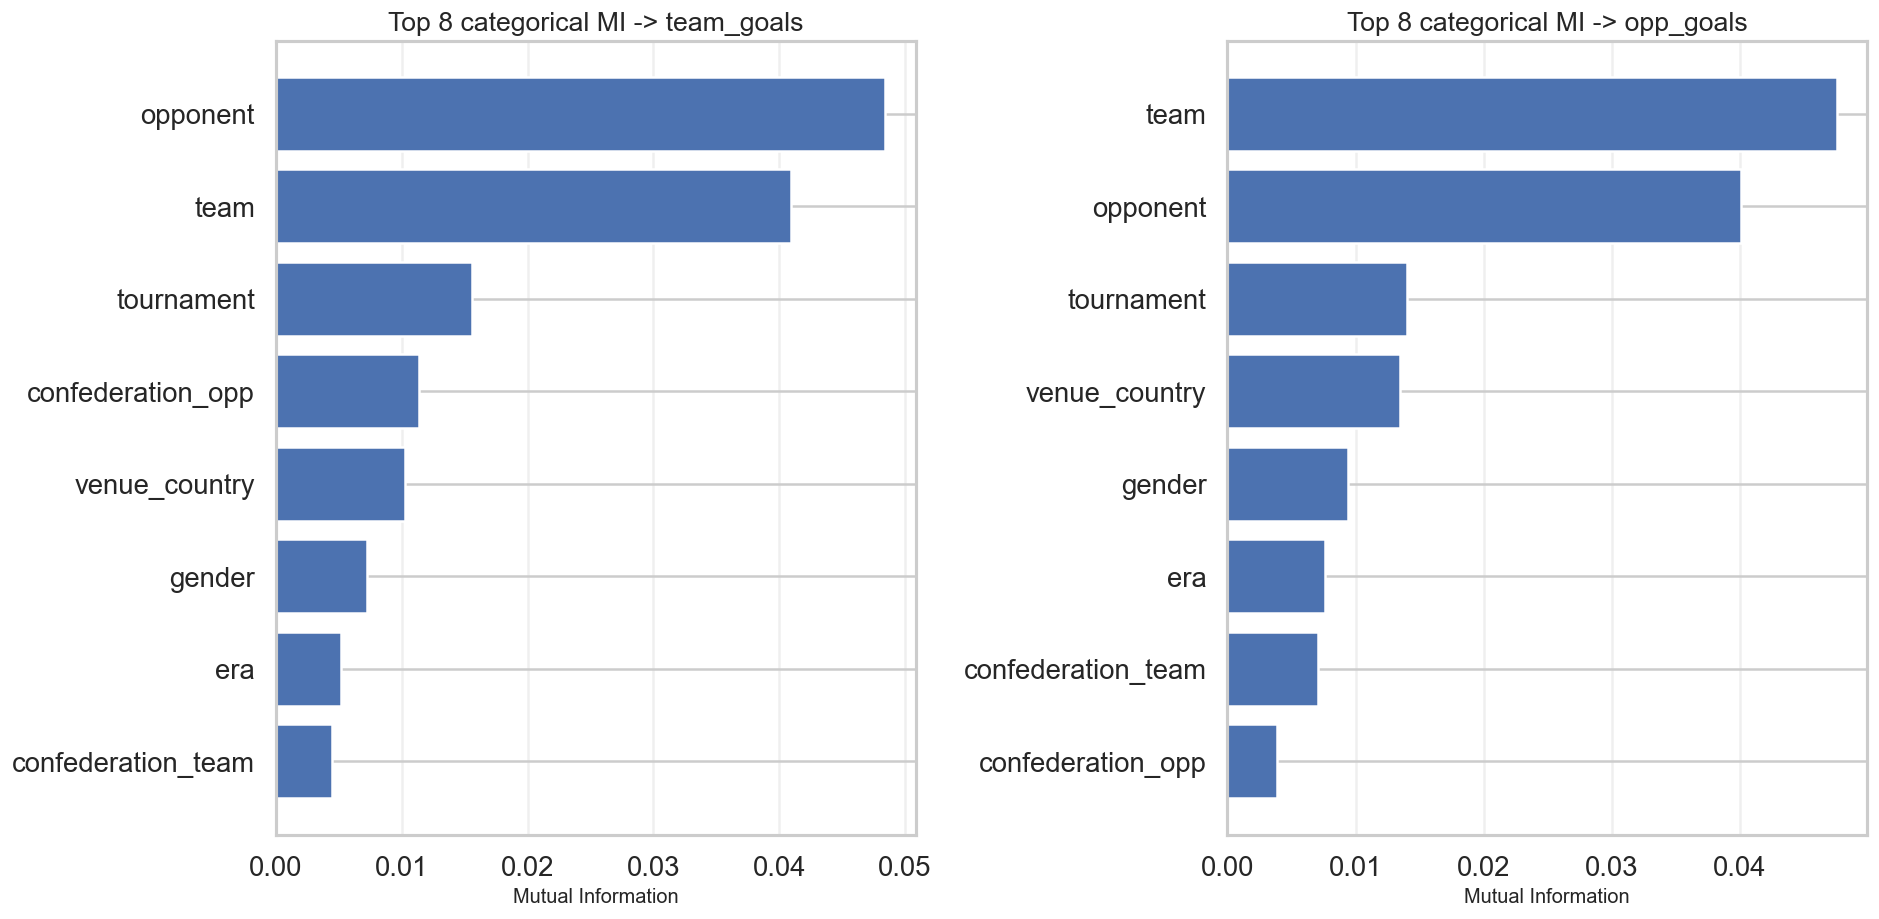

In [51]:
import matplotlib.pyplot as plt

top_n = min(20, len(mi_df))

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

plot_team = mi_df.sort_values('mi_team_goals', ascending=False).head(top_n).sort_values('mi_team_goals')
plot_opp  = mi_df.sort_values('mi_opp_goals', ascending=False).head(top_n).sort_values('mi_opp_goals')

axes[0].barh(plot_team['feature'], plot_team['mi_team_goals'])
axes[0].set_title(f'Top {top_n} categorical MI -> team_goals')
axes[0].set_xlabel('Mutual Information')
axes[0].grid(axis='x', alpha=0.3)

axes[1].barh(plot_opp['feature'], plot_opp['mi_opp_goals'])
axes[1].set_title(f'Top {top_n} categorical MI -> opp_goals')
axes[1].set_xlabel('Mutual Information')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [25]:
# pakai dataframe train yang sudah kamu load
df = train.copy()

# bersihkan sentinel value kalau ada
if 'altitude_venue' in df.columns:
    df['altitude_venue_clean'] = df['altitude_venue'].replace(-9999, np.nan)
else:
    df['altitude_venue_clean'] = np.nan

# ambil hanya fitur numerik
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# pastikan target masuk
targets = ['team_goals', 'opp_goals']
num_cols = [c for c in num_cols if c in df.columns]

# hitung korelasi
corr_to_target = df[num_cols].corr()[targets]

# buang target itu sendiri kalau mau lihat fitur saja
corr_to_target = corr_to_target.drop(index=[c for c in targets if c in corr_to_target.index], errors='ignore')

# tambahkan absolute correlation biar gampang ranking
corr_to_target['abs_team_goals'] = corr_to_target['team_goals'].abs()
corr_to_target['abs_opp_goals'] = corr_to_target['opp_goals'].abs()

# ranking
corr_team = corr_to_target.sort_values('abs_team_goals', ascending=False)[['team_goals']]
corr_opp  = corr_to_target.sort_values('abs_opp_goals', ascending=False)[['opp_goals']]

print("Top korelasi numerik terhadap team_goals")
display(corr_team.head(30))

print("Top korelasi numerik terhadap opp_goals")
display(corr_opp.head(30))

Top korelasi numerik terhadap team_goals


,team_goals
opp_avg_conceded_last5,0.428901
rank_diff,0.365901
gd_last5_diff,0.361488
opp_gd_last5,-0.344786
h2h_gd_last5,0.333771
points_last5_diff,0.300410
opp_points_last5,-0.286238
elo_opponent,-0.280602
opp_points_last10,-0.279083
rank_opponent,0.237578


Top korelasi numerik terhadap opp_goals


,opp_goals
gd_last5_diff,-0.403657
opp_avg_goals_last5,0.401490
rank_diff,-0.365901
h2h_gd_last5,-0.333771
points_last5_diff,-0.323225
team_avg_conceded_last5,0.317644
opp_gd_last5,0.309233
elo_team,-0.282302
h2h_points_last5,-0.255581
team_gd_last5,-0.253808


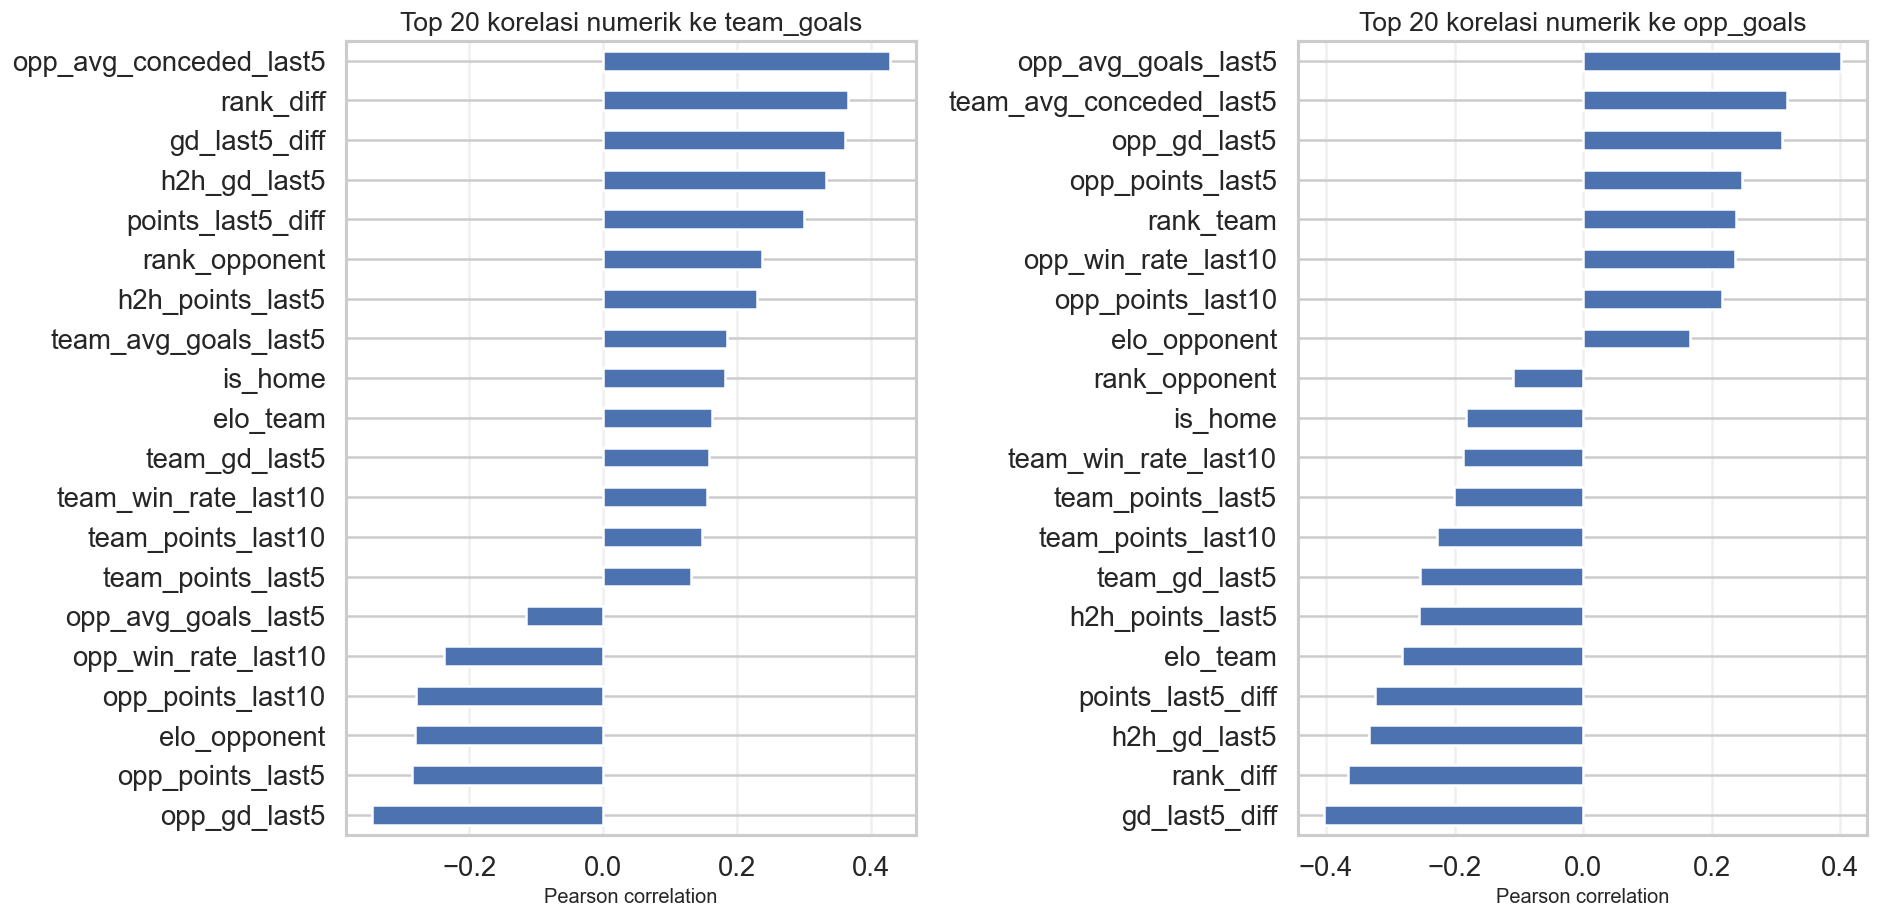

In [26]:
top_n = 20

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

corr_team.head(top_n).sort_values('team_goals').plot(
    kind='barh', ax=axes[0], legend=False
)
axes[0].set_title(f'Top {top_n} korelasi numerik ke team_goals')
axes[0].set_xlabel('Pearson correlation')
axes[0].grid(axis='x', alpha=0.3)

corr_opp.head(top_n).sort_values('opp_goals').plot(
    kind='barh', ax=axes[1], legend=False
)
axes[1].set_title(f'Top {top_n} korelasi numerik ke opp_goals')
axes[1].set_xlabel('Pearson correlation')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [29]:
df_all = train.copy()

# bersihkan sentinel value
if 'altitude_venue' in df_all.columns:
    df_all['altitude_venue_clean'] = df_all['altitude_venue'].replace(-9999, np.nan)

targets = ['team_goals', 'opp_goals']

# optional: buang kolom ID karena korelasinya biasanya tidak bermakna
drop_cols = ['Id', 'match_id']
drop_cols = [c for c in drop_cols if c in df_all.columns]

# optional: ubah date jadi numerik kalau mau ikut dihitung
if 'date' in df_all.columns:
    df_all['date'] = pd.to_datetime(df_all['date'], errors='coerce')
    df_all['date_ordinal'] = df_all['date'].map(lambda x: x.toordinal() if pd.notnull(x) else np.nan)
    df_all = df_all.drop(columns=['date'])

# encode semua kolom non-numerik secara sementara
for col in df_all.columns:
    if col in targets or col in drop_cols:
        continue

    # kalau category
    if str(df_all[col].dtype) == 'category':
        if '__MISSING__' not in df_all[col].cat.categories:
            df_all[col] = df_all[col].cat.add_categories(['__MISSING__'])
        df_all[col] = df_all[col].fillna('__MISSING__')
        df_all[col] = pd.factorize(df_all[col], sort=False)[0]

    # kalau object / string
    elif df_all[col].dtype == 'object':
        df_all[col] = df_all[col].fillna('__MISSING__')
        df_all[col] = pd.factorize(df_all[col], sort=False)[0]

    # kalau bool
    elif df_all[col].dtype == 'bool':
        df_all[col] = df_all[col].astype(int)

# hitung korelasi
corr_all = df_all.drop(columns=drop_cols, errors='ignore').corr(numeric_only=True)[targets]

# buang target dari index
corr_all = corr_all.drop(index=[c for c in targets if c in corr_all.index], errors='ignore')

# absolute value untuk ranking
corr_all['abs_team_goals'] = corr_all['team_goals'].abs()
corr_all['abs_opp_goals'] = corr_all['opp_goals'].abs()

corr_all_team = corr_all.sort_values('abs_team_goals', ascending=False)[['team_goals']]
corr_all_opp  = corr_all.sort_values('abs_opp_goals', ascending=False)[['opp_goals']]

print("Top korelasi SEMUA fitur ke team_goals")
display(corr_all_team.head(50))

print("Top korelasi SEMUA fitur ke opp_goals")
display(corr_all_opp.head(50))

Top korelasi SEMUA fitur ke team_goals


,team_goals
opp_avg_conceded_last5,0.428901
rank_diff,0.365901
gd_last5_diff,0.361488
opp_gd_last5,-0.344786
h2h_gd_last5,0.333771
points_last5_diff,0.300410
opp_points_last5,-0.286238
elo_opponent,-0.280602
opp_points_last10,-0.279083
rank_opponent,0.237578


Top korelasi SEMUA fitur ke opp_goals


,opp_goals
gd_last5_diff,-0.403657
opp_avg_goals_last5,0.401490
rank_diff,-0.365901
h2h_gd_last5,-0.333771
points_last5_diff,-0.323225
team_avg_conceded_last5,0.317644
opp_gd_last5,0.309233
elo_team,-0.282302
h2h_points_last5,-0.255581
team_gd_last5,-0.253808


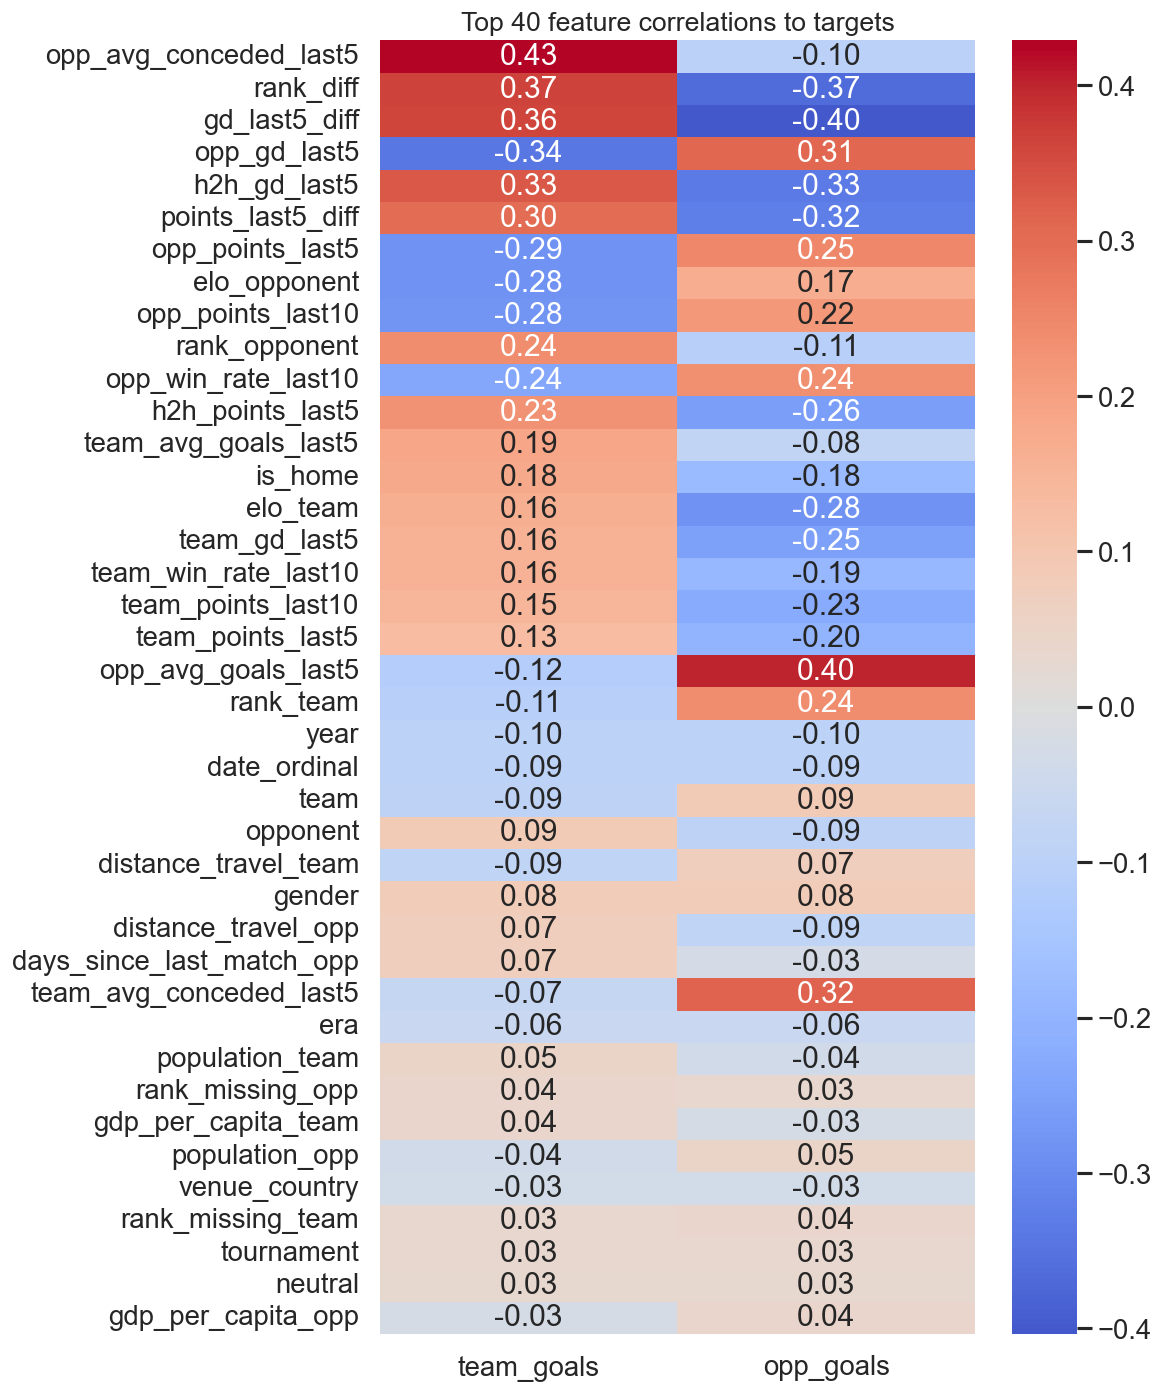

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# pilih hasil yang mau dipakai:
# corr_to_target  -> numerik saja
# corr_all        -> semua fitur setelah encoding sementara

heatmap_df = corr_all[['team_goals', 'opp_goals']].sort_values(
    by='team_goals', key=lambda s: s.abs(), ascending=False
).head(40)

plt.figure(figsize=(8, 14))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Top 40 feature correlations to targets")
plt.show()

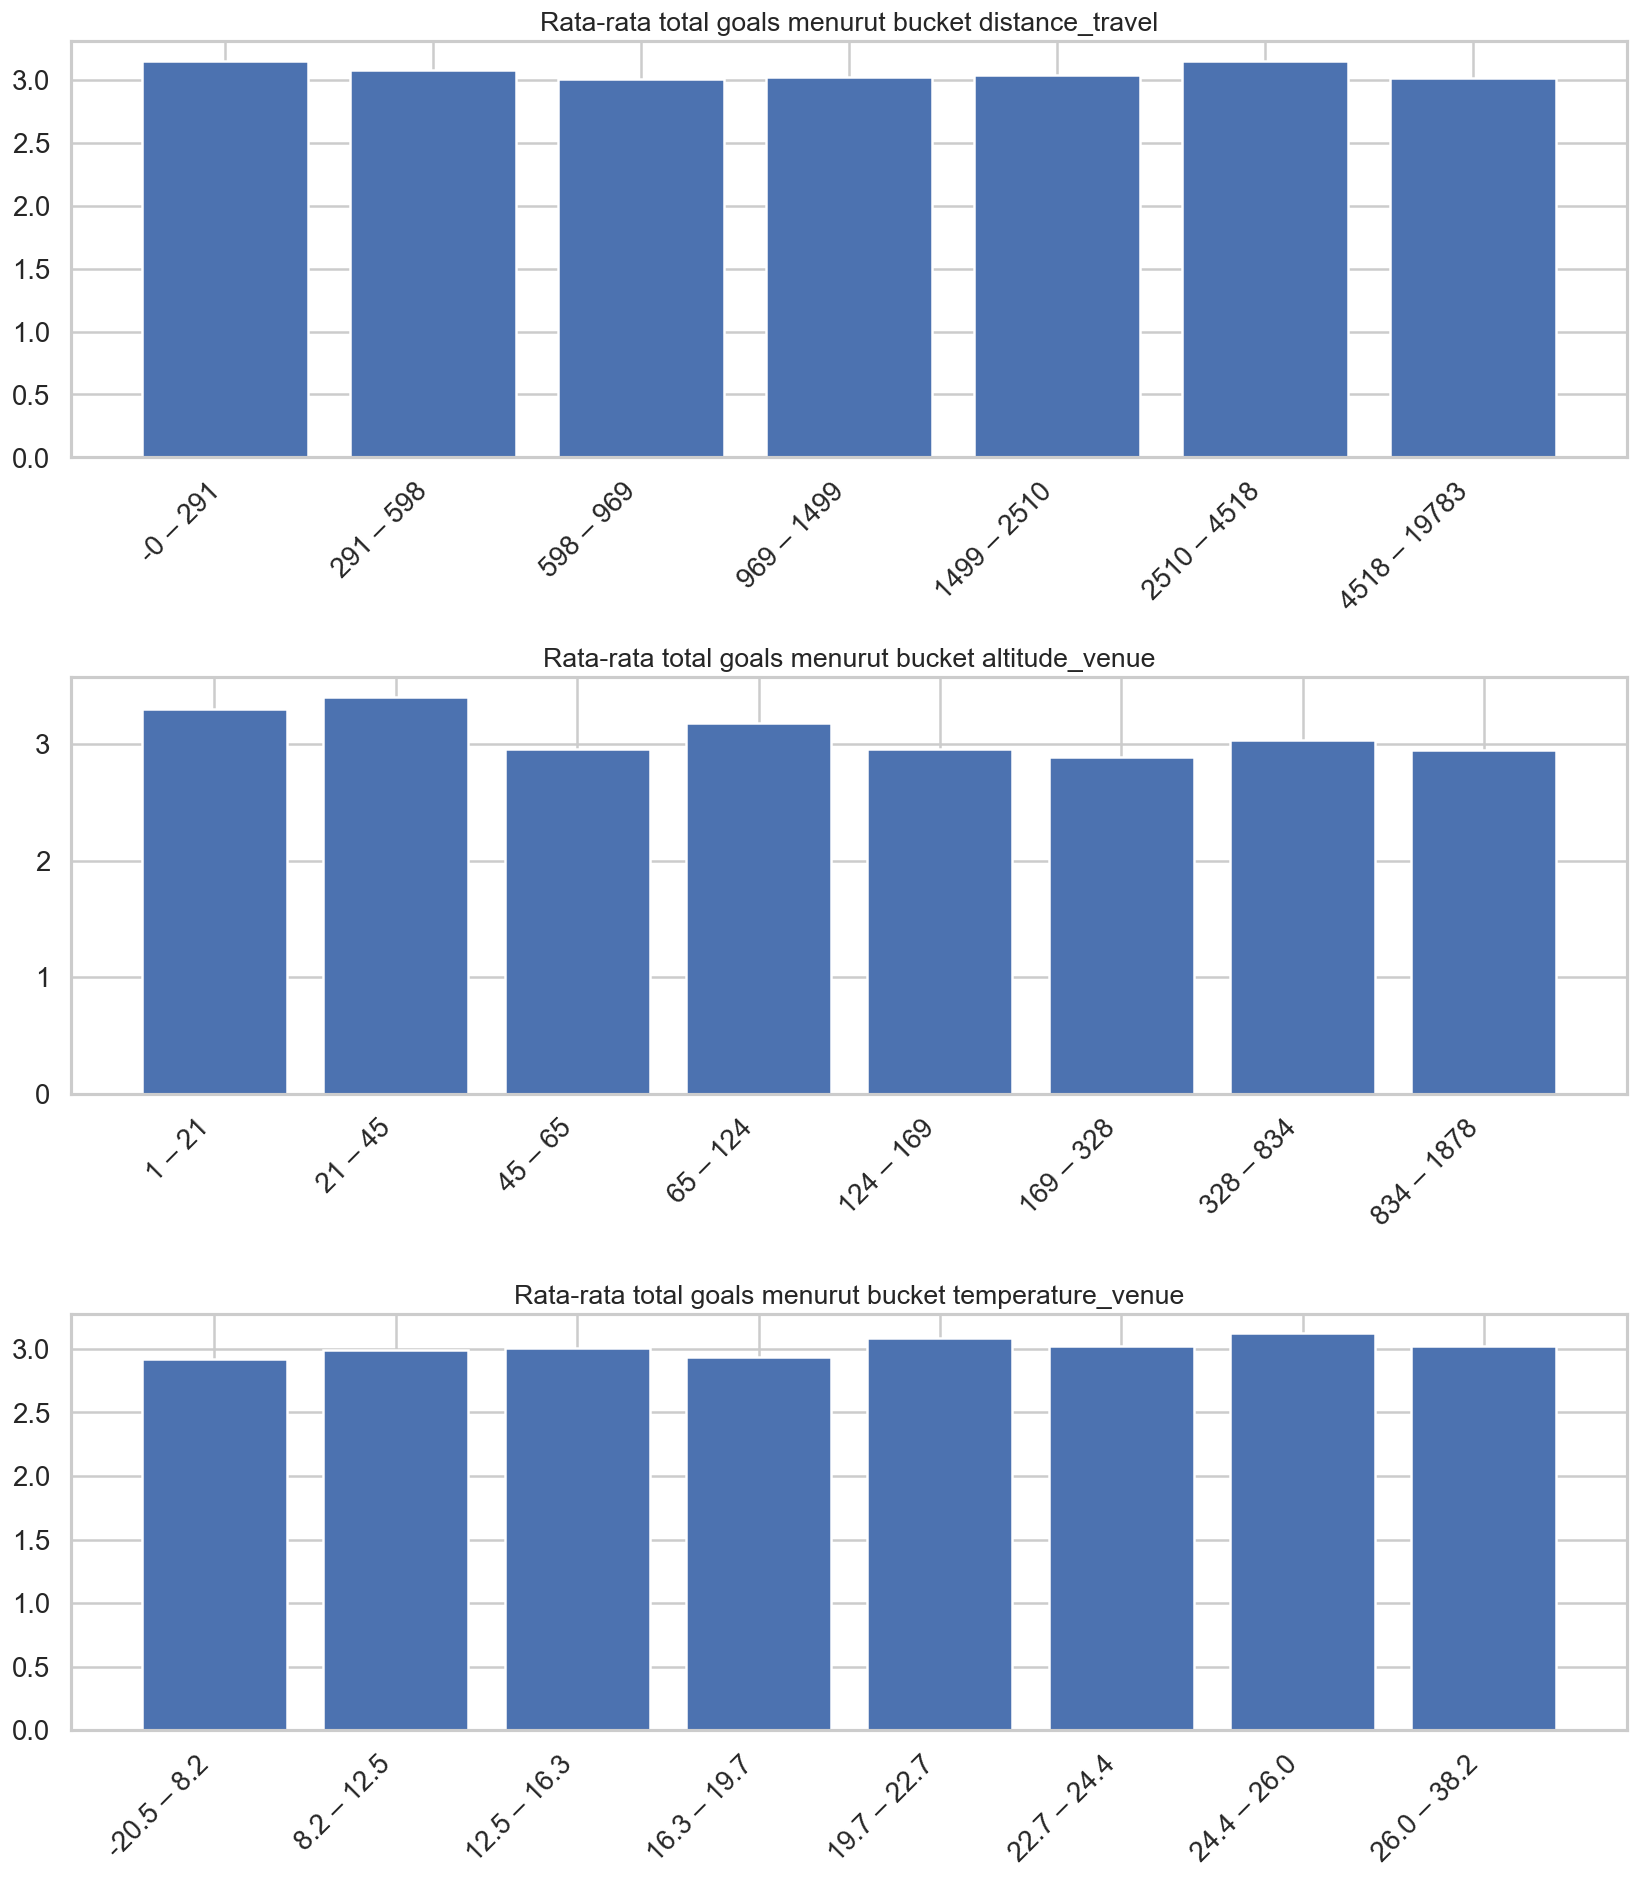

In [18]:
train_match["avg_travel_proxy"] = train_match[["home_distance_travel", "away_distance_travel"]].mean(axis=1)
train_match["avg_travel_bin"] = qcut_with_labels(train_match["avg_travel_proxy"], q=8, precision=0)
train_match["altitude_bin"] = qcut_with_labels(train_match["altitude_venue_clean"], q=8, precision=0)
train_match["temp_bin"] = qcut_with_labels(train_match["temperature_venue"], q=8, precision=1)

bin_travel = train_match.groupby("avg_travel_bin")["total_goals"].mean().reset_index()
bin_alt = train_match.groupby("altitude_bin")["total_goals"].mean().reset_index()
bin_temp = train_match.groupby("temp_bin")["total_goals"].mean().reset_index()

fig, ax = plt.subplots(3, 1, figsize=(14, 16))

ax[0].bar(range(len(bin_travel)), bin_travel["total_goals"])
ax[0].set_title("Rata-rata total goals menurut bucket distance_travel")
ax[0].set_xticks(range(len(bin_travel)))
ax[0].set_xticklabels(bin_travel["avg_travel_bin"], rotation=45, ha="right")

ax[1].bar(range(len(bin_alt)), bin_alt["total_goals"])
ax[1].set_title("Rata-rata total goals menurut bucket altitude_venue")
ax[1].set_xticks(range(len(bin_alt)))
ax[1].set_xticklabels(bin_alt["altitude_bin"], rotation=45, ha="right")

ax[2].bar(range(len(bin_temp)), bin_temp["total_goals"])
ax[2].set_title("Rata-rata total goals menurut bucket temperature_venue")
ax[2].set_xticks(range(len(bin_temp)))
ax[2].set_xticklabels(bin_temp["temp_bin"], rotation=45, ha="right")

plt.tight_layout()
plt.show()

## 12. EDA tim dan matchup

Bagian ini melihat karakter tim dan pasangan tim, terutama untuk menjawab:

- tim mana yang cenderung produktif,
- tim mana yang sering kebobolan,
- matchup apa yang paling sering muncul.

Tim paling produktif (min 80 row)


,team,matches,avg_goals_for,avg_goals_against,win_rate
252,Tahiti,197,2.791878,1.497462,0.553299
128,Jersey,214,2.691589,1.401869,0.626168
174,New Caledonia,200,2.575000,1.525000,0.510000
105,Guernsey,224,2.544643,1.531250,0.575893
34,Brazil,987,2.346505,0.954407,0.633232
94,Germany,1068,2.339888,1.073034,0.602060
180,North Korea,402,2.273632,0.947761,0.482587
84,Fiji,211,2.270142,2.014218,0.445498
195,Papua New Guinea,143,2.265734,2.643357,0.370629
16,Australia,561,2.226381,1.142602,0.500891



Tim paling sering kebobolan (min 80 row)


,team,matches,avg_goals_for,avg_goals_against,win_rate
103,Guam,92,0.978261,6.880435,0.173913
2,Alderney,108,0.462963,4.787037,0.027778
222,San Marino,106,0.160377,4.245283,0.009434
137,Laos,139,1.014388,3.697842,0.194245
37,Brunei,84,0.642857,3.607143,0.083333
146,Macau,95,0.747368,3.589474,0.136842
176,Nicaragua,131,0.786260,3.458015,0.129771
198,Philippines,254,0.889764,3.437008,0.165354
203,Puerto Rico,107,1.028037,3.037383,0.196262
151,Maldives,136,0.992647,2.970588,0.213235


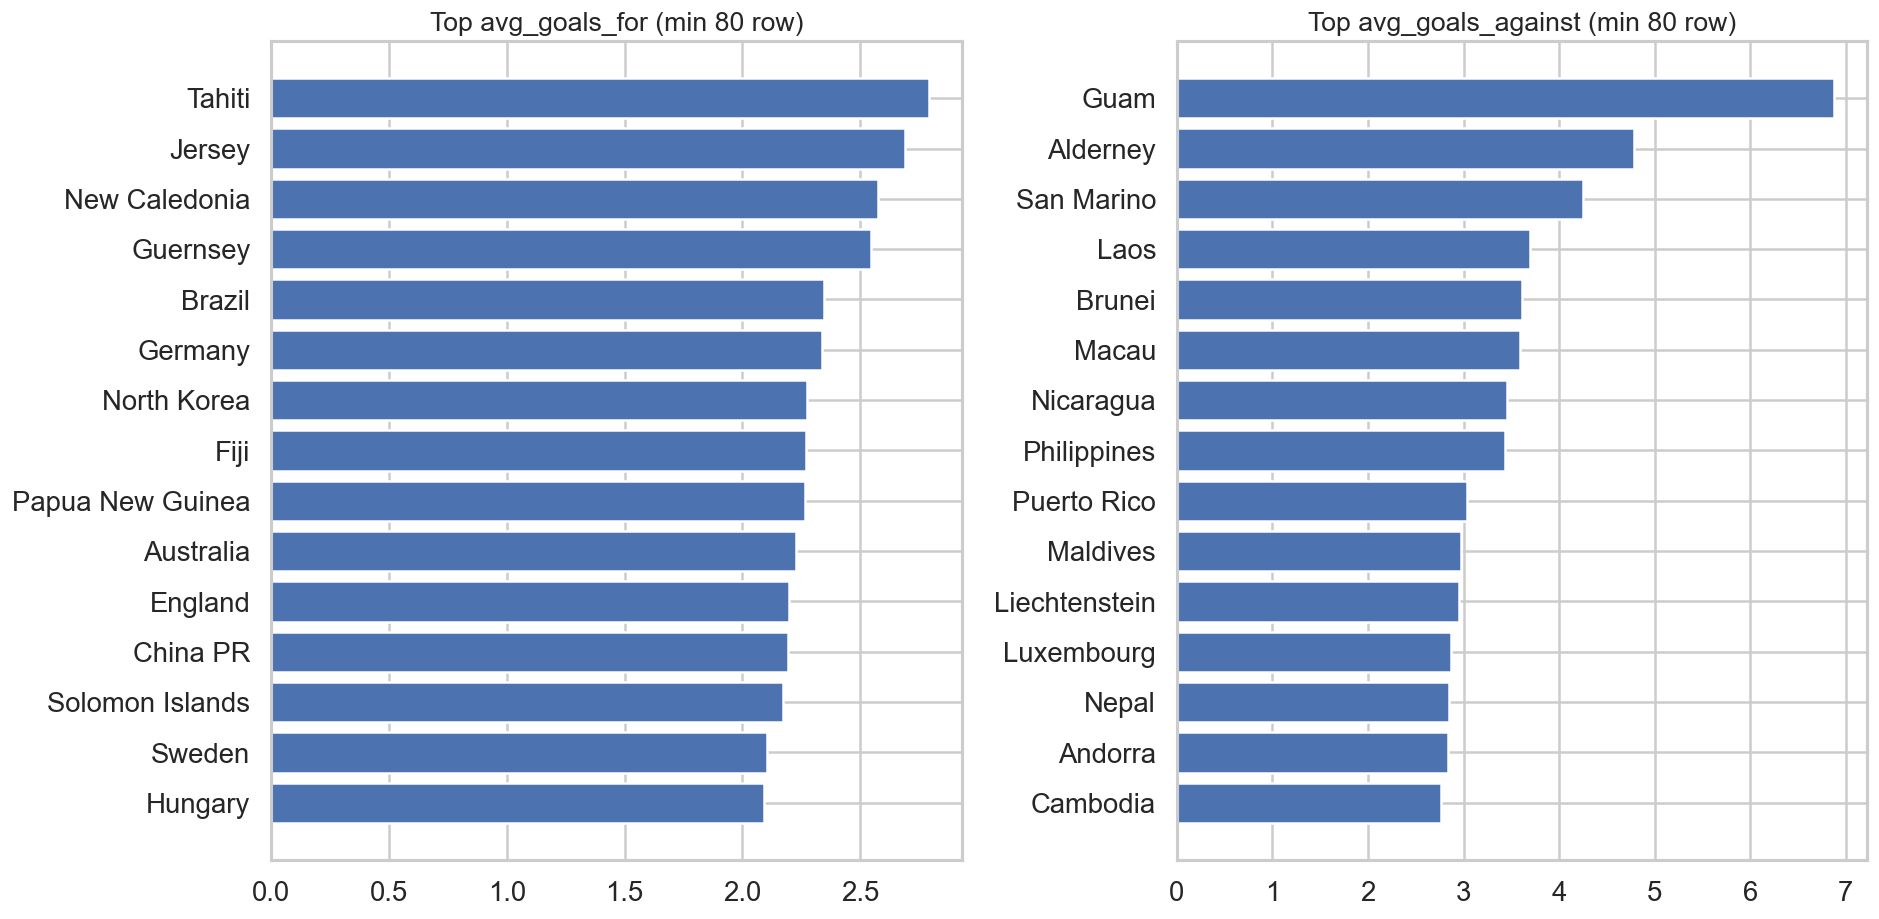

,matchup,matches
0,Argentina vs Uruguay,176
1,Austria vs Hungary,138
2,Denmark vs Sweden,137
3,Belgium vs Netherlands,132
4,Norway vs Sweden,127
5,England vs Scotland,122
6,Denmark vs Norway,112
7,Guernsey vs Jersey,111
8,Scotland vs Wales,109
9,Finland vs Sweden,109


In [19]:
team_stats = train.groupby("team").agg(
    matches=("match_id", "count"),
    avg_goals_for=("team_goals", "mean"),
    avg_goals_against=("opp_goals", "mean"),
).reset_index()

wins_by_team = train.assign(win=(train["team_goals"] > train["opp_goals"]).astype(int)).groupby("team")["win"].sum().reset_index(name="wins")
team_stats = team_stats.merge(wins_by_team, on="team", how="left")
team_stats["win_rate"] = team_stats["wins"] / team_stats["matches"]

team_stats_filtered = team_stats[team_stats["matches"] >= 80].copy()

top_attack = team_stats_filtered.sort_values("avg_goals_for", ascending=False).head(15)
top_conceded = team_stats_filtered.sort_values("avg_goals_against", ascending=False).head(15)

print("Tim paling produktif (min 80 row)")
display(top_attack[["team", "matches", "avg_goals_for", "avg_goals_against", "win_rate"]])

print()
print("Tim paling sering kebobolan (min 80 row)")
display(top_conceded[["team", "matches", "avg_goals_for", "avg_goals_against", "win_rate"]])

fig, ax = plt.subplots(1, 2, figsize=(16, 8))
attack_plot = top_attack.sort_values("avg_goals_for")
conceded_plot = top_conceded.sort_values("avg_goals_against")
ax[0].barh(attack_plot["team"], attack_plot["avg_goals_for"])
ax[0].set_title("Top avg_goals_for (min 80 row)")
ax[1].barh(conceded_plot["team"], conceded_plot["avg_goals_against"])
ax[1].set_title("Top avg_goals_against (min 80 row)")

plt.tight_layout()
plt.show()

pair_df = train_match.copy()
pair_df["matchup"] = pair_df.apply(lambda r: " vs ".join(sorted([r["home_team"], r["away_team"]])), axis=1)
top_matchups = pair_df["matchup"].value_counts().head(15).rename_axis("matchup").reset_index(name="matches")
display(top_matchups)

## 13. EDA era modern vs era lama

Dataset train sangat panjang, dari abad ke-19 sampai 2011. Jadi kita perlu tahu apakah era lama dan era modern punya karakter yang berbeda.

,era,matches,avg_total_goals,median_total_goals,draw_rate,home_win_rate,w_share
0,<=1949,3334,4.238152,4.0,16.26%,52.67%,0.00%
1,1950-1989,14247,3.049765,3.0,22.29%,49.72%,3.28%
2,1990-2005,14856,3.028743,3.0,22.42%,50.18%,15.10%
3,2006-2011,6949,2.957980,3.0,20.55%,49.24%,24.36%


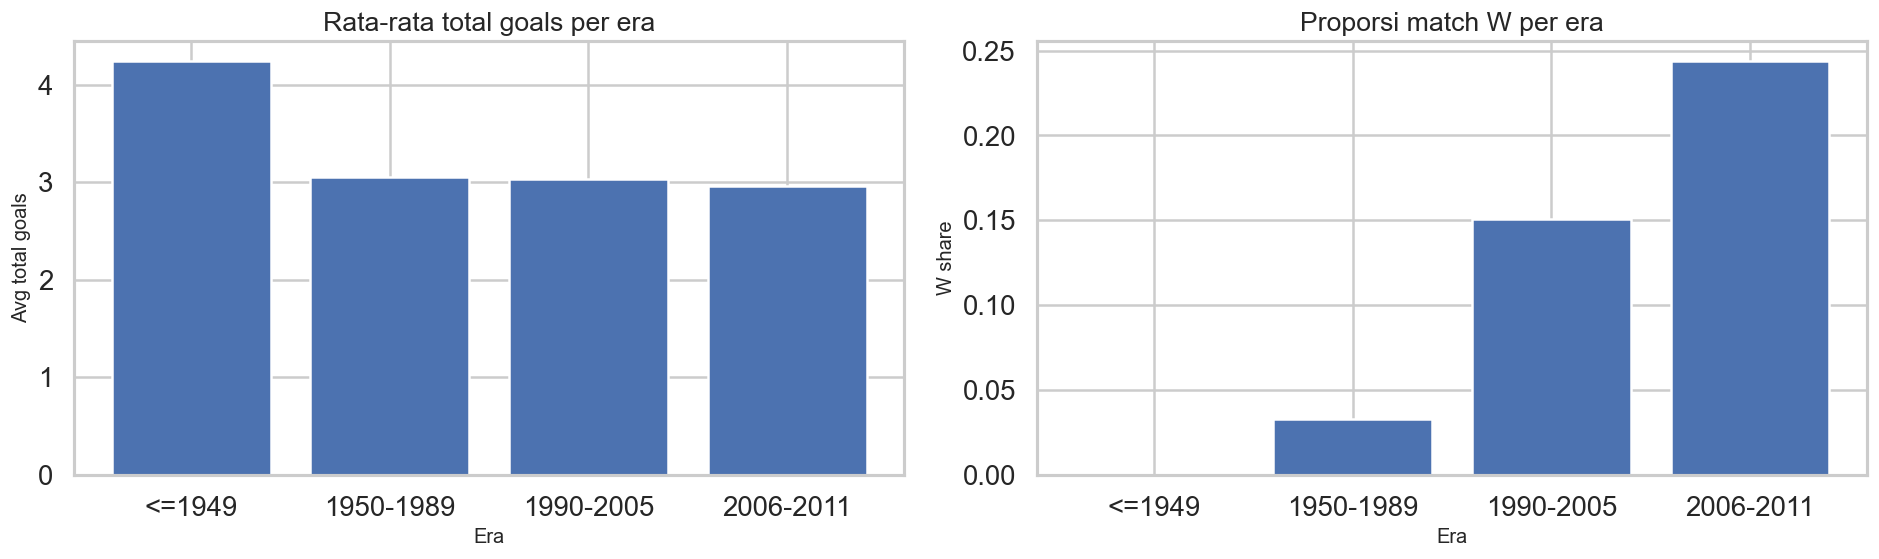

In [20]:
train_match["era"] = pd.cut(
    train_match["year"],
    bins=[1871, 1949, 1989, 2005, 2011],
    labels=["<=1949", "1950-1989", "1990-2005", "2006-2011"]
)

era_stats = train_match.groupby("era").agg(
    matches=("match_id", "count"),
    avg_total_goals=("total_goals", "mean"),
    median_total_goals=("total_goals", "median"),
    draw_rate=("outcome", lambda s: (s == "Draw").mean()),
    home_win_rate=("outcome", lambda s: (s == "Home Win").mean()),
    w_share=("gender", lambda s: (s == "W").mean()),
).reset_index()

display(style_pct_columns(era_stats, ["draw_rate", "home_win_rate", "w_share"]))

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
ax[0].bar(era_stats["era"].astype(str), era_stats["avg_total_goals"])
ax[0].set_title("Rata-rata total goals per era")
ax[0].set_xlabel("Era")
ax[0].set_ylabel("Avg total goals")

ax[1].bar(era_stats["era"].astype(str), era_stats["w_share"])
ax[1].set_title("Proporsi match W per era")
ax[1].set_xlabel("Era")
ax[1].set_ylabel("W share")

plt.tight_layout()
plt.show()

## 14. EDA yang membantu desain validasi

Bagian ini mencoba menjawab: validasi seperti apa yang paling realistis?

Kita bandingkan:

- seluruh train,
- train yang lebih recent,
- test.

,segment,rows,matches,date_min,date_max,w_share_match,neutral_share_match,unique_teams,unique_tournaments
0,All train,78772,39386,1872-11-30,2011-08-04,11.18%,26.90%,294,186
1,Recent train (2002-2011),22782,11391,2002-01-04,2011-08-04,22.27%,31.63%,278,99
2,Test,42422,21211,2011-08-06,2026-03-31,32.90%,33.02%,315,167


,feature,test_coverage_by_all_train,test_coverage_by_recent_train
0,team,98.83%,98.74%
1,tournament,86.13%,84.81%
2,venue_country,99.43%,99.23%


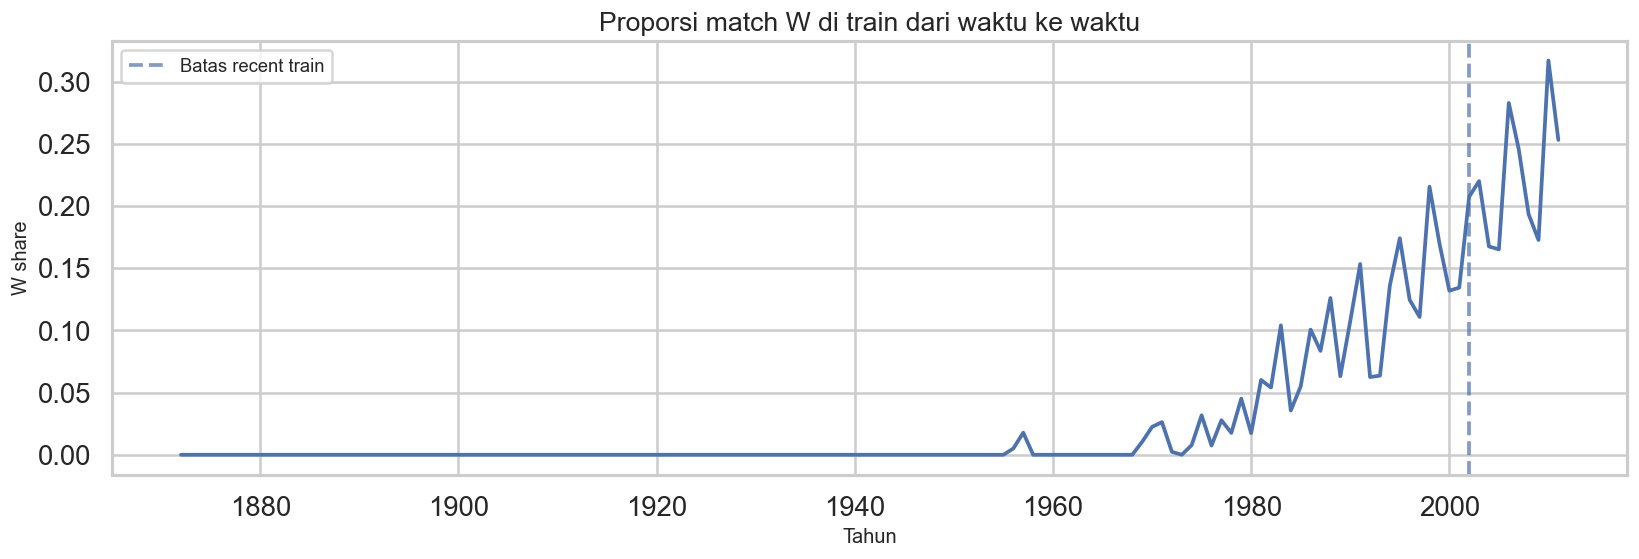

In [21]:
recent_cutoff = train["year"].max() - 9
train_recent = train[train["year"] >= recent_cutoff].copy()
train_recent_match = train_match[train_match["year"] >= recent_cutoff].copy()

segment_summary = pd.DataFrame({
    "segment": ["All train", f"Recent train ({recent_cutoff}-{train['year'].max()})", "Test"],
    "rows": [len(train), len(train_recent), len(test)],
    "matches": [train["match_id"].nunique(), train_recent["match_id"].nunique(), test["match_id"].nunique()],
    "date_min": [train["date"].min().date(), train_recent["date"].min().date(), test["date"].min().date()],
    "date_max": [train["date"].max().date(), train_recent["date"].max().date(), test["date"].max().date()],
    "w_share_match": [
        (train_match["gender"] == "W").mean(),
        (train_recent_match["gender"] == "W").mean(),
        (test_match["gender"] == "W").mean(),
    ],
    "neutral_share_match": [
        train_match["neutral"].mean(),
        train_recent_match["neutral"].mean(),
        test_match["neutral"].mean(),
    ],
    "unique_teams": [
        train["team"].nunique(),
        train_recent["team"].nunique(),
        test["team"].nunique(),
    ],
    "unique_tournaments": [
        train["tournament"].nunique(),
        train_recent["tournament"].nunique(),
        test["tournament"].nunique(),
    ],
})

display(style_pct_columns(segment_summary, ["w_share_match", "neutral_share_match"]))

coverage_summary = pd.DataFrame({
    "feature": ["team", "tournament", "venue_country"],
    "test_coverage_by_all_train": [
        test["team"].isin(set(train["team"])).mean(),
        test["tournament"].isin(set(train["tournament"])).mean(),
        test["venue_country"].isin(set(train["venue_country"])).mean(),
    ],
    "test_coverage_by_recent_train": [
        test["team"].isin(set(train_recent["team"])).mean(),
        test["tournament"].isin(set(train_recent["tournament"])).mean(),
        test["venue_country"].isin(set(train_recent["venue_country"])).mean(),
    ],
})
display(style_pct_columns(coverage_summary, ["test_coverage_by_all_train", "test_coverage_by_recent_train"]))

w_share_yearly = train_match.groupby("year").apply(lambda d: (d["gender"] == "W").mean()).reset_index(name="w_share")
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(w_share_yearly["year"], w_share_yearly["w_share"])
ax.axvline(recent_cutoff, linestyle="--", alpha=0.7, label="Batas recent train")
ax.set_title("Proporsi match W di train dari waktu ke waktu")
ax.set_xlabel("Tahun")
ax.set_ylabel("W share")
ax.legend()
plt.tight_layout()
plt.show()

## 15. EDA rare categories

Kategori langka dan unseen category sering membuat model lebih rapuh. Di sini kita lihat seberapa besar masalah ini.

,column,train_unique,train_categories_lt5,train_categories_lt10,test_share_with_train_freq_lt10,test_share_unseen
0,team,294,22,32,0.65%,1.17%
1,tournament,186,14,31,0.26%,13.87%
2,venue_country,268,10,21,0.47%,0.57%


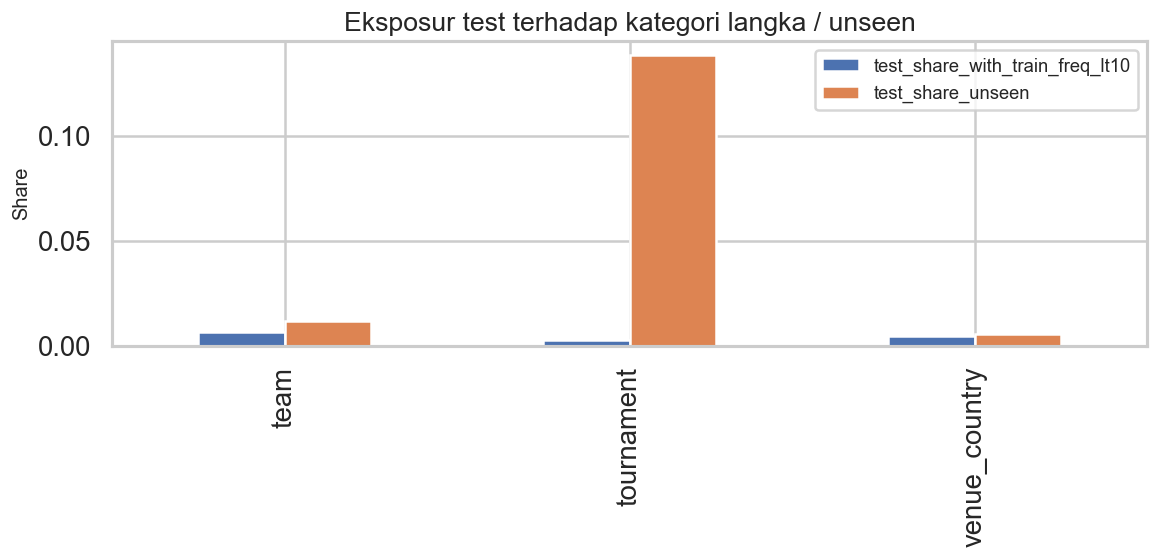

Contoh unseen tournaments di test


,unseen_tournament_example
0,AFF Women's Cup
1,ASEAN Championship
2,ASEAN Championship qualification
3,Africa Cup of Nations qualification
4,Aisha Buhari Cup
5,Al Ain International Cup
6,Aphrodite Cup
7,Armenia International Friendly Tournament
8,Arnold Clark Cup
9,Atlantic Heritage Cup


In [22]:
rare_rows = []
for col in ["team", "tournament", "venue_country"]:
    train_vc = train[col].value_counts()
    rare_lt5 = set(train_vc[train_vc < 5].index)
    rare_lt10 = set(train_vc[train_vc < 10].index)
    unseen = set(test[col]) - set(train[col])

    rare_rows.append({
        "column": col,
        "train_unique": train[col].nunique(),
        "train_categories_lt5": len(rare_lt5),
        "train_categories_lt10": len(rare_lt10),
        "test_share_with_train_freq_lt10": test[col].isin(rare_lt10).mean(),
        "test_share_unseen": test[col].isin(unseen).mean(),
    })

rare_summary = pd.DataFrame(rare_rows)
display(style_pct_columns(rare_summary, ["test_share_with_train_freq_lt10", "test_share_unseen"]))

plot_rare = rare_summary.set_index("column")[["test_share_with_train_freq_lt10", "test_share_unseen"]]
fig, ax = plt.subplots(figsize=(10, 5))
plot_rare.plot(kind="bar", ax=ax)
ax.set_title("Eksposur test terhadap kategori langka / unseen")
ax.set_xlabel("")
ax.set_ylabel("Share")
plt.tight_layout()
plt.show()

unseen_tournaments = sorted(set(test["tournament"]) - set(train["tournament"]))
print("Contoh unseen tournaments di test")
display(pd.DataFrame({"unseen_tournament_example": unseen_tournaments[:30]}))

## Ringkasan insight utama

Bagian akhir ini merangkum insight paling penting dari EDA, supaya lebih mudah dipakai untuk menyusun pendekatan modeling nanti.

In [24]:
summary_lines = [
    "### Insight utama dari EDA",
    "",
    "1. **Format data sangat konsisten**  ",
    "   Setiap pertandingan benar-benar direpresentasikan sebagai **2 row per match**, dengan target dan metadata yang mirror secara rapi.",
    "",
    "2. **Masalah ini adalah prediksi count dengan tail yang panjang**  ",
    f"   Rata-rata total gol per match ada di sekitar **{train_match['total_goals'].mean():.2f}**, tetapi masih ada pertandingan ekstrem sampai total gol **{train_match['total_goals'].max()}**.",
    "",
    "3. **Temporal split wajib**  ",
    f"   Train berakhir di **{train['date'].max().date()}** dan test mulai di **{test['date'].min().date()}**, jadi random CV akan memberi gambaran yang terlalu optimistis.",
    "",
    "4. **Ada train–test shift yang nyata**  ",
    f"   Proporsi match `W` di train = **{pct((train_match['gender'] == 'W').mean())}**, sedangkan di test = **{pct((test_match['gender'] == 'W').mean())}**.",
    "",
    "5. **Pertandingan `W` cenderung lebih high-scoring**  ",
    "   Jadi perubahan komposisi gender kemungkinan besar akan memengaruhi distribusi target.",
    "",
    "6. **Ada unseen categories di test**  ",
    f"   Misalnya unseen `team` = **{len(set(test['team']) - set(train['team']))}**, unseen `tournament` = **{len(set(test['tournament']) - set(train['tournament']))}**.",
    "",
    "7. **Banyak missing value dan ada sentinel value**  ",
    "   Ranking hilang dalam proporsi besar, dan `altitude_venue = -9999` harus diperlakukan sebagai invalid / missing, bukan angka asli.",
    "",
    "8. **Tidak semua fitur train bisa langsung dipakai nanti**  ",
    f"   Ada **{len(train_only_cols)} kolom train-only**, termasuk banyak fitur history, rank, dan Elo.",
    "",
    "9. **Era lama dan era modern punya karakter berbeda**  ",
    "   Rata-rata goal, proporsi `W`, dan ketersediaan fitur berubah cukup besar antar-era.",
    "",
    "10. **EDA ini mengarah ke kebutuhan pipeline yang hati-hati**  ",
    "    Pipeline nanti sangat mungkin perlu:",
    "    - validasi time-based,",
    "    - perhatian khusus pada train–test shift,",
    "    - penanganan unseen categories,",
    "    - dan evaluasi terpisah per segmen seperti gender / tournament / tail-score.",
]

display(Markdown(chr(10).join(summary_lines)))

### Insight utama dari EDA

1. **Format data sangat konsisten**  
   Setiap pertandingan benar-benar direpresentasikan sebagai **2 row per match**, dengan target dan metadata yang mirror secara rapi.

2. **Masalah ini adalah prediksi count dengan tail yang panjang**  
   Rata-rata total gol per match ada di sekitar **3.13**, tetapi masih ada pertandingan ekstrem sampai total gol **31**.

3. **Temporal split wajib**  
   Train berakhir di **2011-08-04** dan test mulai di **2011-08-06**, jadi random CV akan memberi gambaran yang terlalu optimistis.

4. **Ada train–test shift yang nyata**  
   Proporsi match `W` di train = **11.18%**, sedangkan di test = **32.90%**.

5. **Pertandingan `W` cenderung lebih high-scoring**  
   Jadi perubahan komposisi gender kemungkinan besar akan memengaruhi distribusi target.

6. **Ada unseen categories di test**  
   Misalnya unseen `team` = **50**, unseen `tournament` = **87**.

7. **Banyak missing value dan ada sentinel value**  
   Ranking hilang dalam proporsi besar, dan `altitude_venue = -9999` harus diperlakukan sebagai invalid / missing, bukan angka asli.

8. **Tidak semua fitur train bisa langsung dipakai nanti**  
   Ada **27 kolom train-only**, termasuk banyak fitur history, rank, dan Elo.

9. **Era lama dan era modern punya karakter berbeda**  
   Rata-rata goal, proporsi `W`, dan ketersediaan fitur berubah cukup besar antar-era.

10. **EDA ini mengarah ke kebutuhan pipeline yang hati-hati**  
    Pipeline nanti sangat mungkin perlu:
    - validasi time-based,
    - perhatian khusus pada train–test shift,
    - penanganan unseen categories,
    - dan evaluasi terpisah per segmen seperti gender / tournament / tail-score.